In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# clean 처리된 데이터 불러오기
df = pd.read_csv('merged_data_clean.csv')

# 컬럼 그룹 정의 (X값 후보만) — clean 컬럼명 기준
core_cols = ['페니실린농도_P', '기질농도_S', '용존산소_DO2', '발효조부피_V', 'pH', '발효온도_T']

operating_cols = ['교반속도_RPM', '당공급유량_Fs', '공기주입유량_Fg', '산투입유량_Fa',
                  '염기투입유량_Fb', '냉난방수유량_Fc', '가열수유량_Fh', '희석수유량_Fw',
                  'PAA투입유량_Fpaa', '오일투입유량_Foil', '발효조상부압력',
                  '발생열량_Q', '발효조중량_Wt', '배양액제거유량_Fremoved',
                  '암모니아투입량_NH3', '배가스CO2_CO2out', '배가스O2_O2out',
                  '산소소비율_OUR', '이산화탄소발생률_CER']

offline_cols = ['바이오매스농도_오프라인', '페니실린농도_오프라인', 'PAA농도_오프라인',
                '암모니아농도_오프라인', '점도_오프라인']

y_cols = ['총회수량', '종료수확량', '중간수확량']

# 컬럼명 변수 재지정 (기존 코드가 그대로 돌아가도록)
batch_col = '배치번호'
strategy_col = '제어전략그룹'
time_col = '발효시간'

total_col = '총회수량'
during_col = '중간수확량'
end_col = '종료수확량'

p_col = '페니실린농도_P'
s_col = '기질농도_S'
volume_col = '발효조부피_V'

# 시간순 정렬
df = df.sort_values([batch_col, time_col]).copy()

# 배치별 제어전략 그룹 컬럼 대치
df['Strategy'] = df['제어전략그룹']

# 1. Train/Test 배치 단위 분할 확인

In [2]:
# 같은 배치의 시계열이 Train과 Test에 섞이지 않도록
# Batch_ID를 그룹으로 지정해 분할
gss = GroupShuffleSplit(
    n_splits=1,       # 한 번 분할
    test_size=0.2,    # 전체 배치 중 20%를 Test로 사용
    random_state=42   # 팀 전체가 같은 분할을 재현하도록 고정
)

# groups에 Batch_ID를 넣어 배치 단위로 분할
train_idx, test_idx = next(
    gss.split(df, groups=df[batch_col])
)

# 분할된 행으로 Train/Test 데이터 생성
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

# Train/Test에 들어간 고유 배치번호 확인
train_batches = sorted(train_df[batch_col].unique())
test_batches = sorted(test_df[batch_col].unique())

print('Train 배치 수:', len(train_batches))
print('Test 배치 수:', len(test_batches))

print('\nTrain 전략별 배치 수')
print(
    train_df.groupby('Strategy')[batch_col]
    .nunique()
    .reindex(['RC', 'OC', 'APC', 'Fault'])
)

print('\nTest 전략별 배치 수')
print(
    test_df.groupby('Strategy')[batch_col]
    .nunique()
    .reindex(['RC', 'OC', 'APC', 'Fault'])
)

# 같은 배치가 양쪽에 동시에 들어갔는지 확인
overlap = set(train_batches) & set(test_batches)

print('\nTrain/Test 중복 배치:', sorted(overlap))

if len(overlap) == 0:
    print('Train과 Test에 중복된 배치가 없습니다.')
else:
    print('Train과 Test에 같은 배치가 포함되어 있습니다.')

Train 배치 수: 80
Test 배치 수: 20

Train 전략별 배치 수
Strategy
RC       24
OC       23
APC      24
Fault     9
Name: 배치번호, dtype: int64

Test 전략별 배치 수
Strategy
RC       6
OC       7
APC      6
Fault    1
Name: 배치번호, dtype: int64

Train/Test 중복 배치: []
Train과 Test에 중복된 배치가 없습니다.


### 1. 결과 해석

- 전체 100개 배치가 Train 80개, Test 20개로 정상 분리됐다.
- Train과 Test에 중복 배치가 없으므로 같은 배치의 유사한 시계열 값이 양쪽에 섞이는 데이터 누수를 방지했다.
- 이후 골든배치 후보와 상·하위 20% 기준은 Train 80개 배치만 사용해 선정해야 한다.
- Test의 Fault 배치는 1개뿐이므로, 향후 Test 결과만으로 Fault 그룹의 성능을 일반화하지 않는다.
- random_state=42를 사용했기 때문에 팀원들도 같은 Train/Test 구성을 재현할 수 있다.

배치 단위 Train/Test 분할 결과, 양쪽에 중복된 배치가 없는 것을 확인했다. 따라서 골든배치 선정과 모델 개발에는 Train 배치만 사용하고, Test 배치는 최종 평가 단계까지 제외한다.

# 2. Train 데이터를 배치당 한 행으로 정리

In [3]:
total_nunique = (
    train_df.groupby(batch_col)[total_col]
    .nunique()
)

print('배치 내 총회수량 고유값 개수의 최댓값:',
      total_nunique.max())

if total_nunique.max() == 1:
    print('총회수량은 모든 배치 안에서 고정값입니다.')
else:
    print('한 배치 안에서 총회수량이 변하는 경우가 있습니다.')


# 배치마다 총회수량이 고정되어 있으므로 first()로 대표값 추출
# 결과적으로 Train 배치 80개가 각각 한 행으로 정리됨
batch_summary = (
    train_df
    .groupby([batch_col, 'Strategy'], as_index=False)
    .agg(
        총회수량=(total_col, 'first')
    )
)

print('\n배치 요약 데이터 크기:', batch_summary.shape)

print('\n전략별 배치 수')
print(
    batch_summary['Strategy']
    .value_counts()
    .reindex(['RC', 'OC', 'APC', 'Fault'])
)

print('\n배치 요약 데이터 앞부분')
display(batch_summary.head(10))

배치 내 총회수량 고유값 개수의 최댓값: 1
총회수량은 모든 배치 안에서 고정값입니다.

배치 요약 데이터 크기: (80, 3)

전략별 배치 수
Strategy
RC       24
OC       23
APC      24
Fault     9
Name: count, dtype: int64

배치 요약 데이터 앞부분


,배치번호,Strategy,총회수량
0,2,RC,2326000.0
1,3,RC,2675300.0
2,4,RC,1886700.0
3,6,RC,2388700.0
4,7,RC,3454600.0
5,8,RC,3877400.0
6,9,RC,4083100.0
7,10,RC,1982000.0
8,12,RC,3970100.0
9,14,RC,3585600.0


### 2. 결과 해석
 총회수량의 배치 내 고유값이 모두 1개이므로, 총회수량은 시간에 따라 변하는 센서값이 아니라 배치별로 하나씩 부여된 성과지표임을 확인했다.
 
- Train 데이터가 배치당 한 행으로 정리되어 (80, 3) 형태가 됐다.
- 전략별 배치 수도 Step 1과 동일하므로 요약 과정에서 빠지거나 중복된 배치가 없다.
- 이제 시계열 행 개수의 영향을 받지 않고, 배치별 총회수량을 동일한 단위로 비교할 수 있다.
- 1·5·11번처럼 표에 보이지 않는 번호가 있는 것은 해당 배치가 Test에 포함됐기 때문이며 정상이다.

총회수량은 배치 내 고정값임을 확인했다. 따라서 Train 데이터에서 배치당 한 행의 요약 데이터를 생성했으며, 이후 골든배치 후보 선정은 이 배치 단위 데이터를 기준으로 진행한다.

# 3. 전략별 상하위 20% 선정 개수 계산

In [4]:
# 현재는 정상 운전전략인 RC·OC·APC만 계산
# Fault 포함 여부는 아직 최종 결정 전이므로 제외
target_strategies = ['RC', 'OC', 'APC']

selection_count = []

for strategy in target_strategies:

    # 해당 전략의 Train 배치 수
    n_batches = len(
        batch_summary[
            batch_summary['Strategy'] == strategy
        ]
    )

    # 배치 수의 정확한 20%
    raw_20pct = n_batches * 0.20

    # 소수점 버림 시 선정 개수
    floor_count = int(raw_20pct)

    # 소수점 올림 시 선정 개수
    ceil_count = math.ceil(raw_20pct)

    selection_count.append({
        'Strategy': strategy,
        'Train_배치수': n_batches,
        '배치수×20%': raw_20pct,
        '버림_선정수': floor_count,
        '올림_선정수': ceil_count,
        '실제_선정비율(%)': ceil_count / n_batches * 100
    })

# 결과를 표로 변환
selection_count_df = pd.DataFrame(selection_count)

display(selection_count_df.round(2))

,Strategy,Train_배치수,배치수×20%,버림_선정수,올림_선정수,실제_선정비율(%)
0,RC,24,4.8,4,5,20.83
1,OC,23,4.6,4,5,21.74
2,APC,24,4.8,4,5,20.83


### 3. 결과 해석

- RC와 APC는 Train 배치가 각각 24개이므로 20%는 4.8개다.
- OC는 Train 배치가 23개이므로 20%는 4.6개다.
- 배치 일부만 선택할 수 없으므로 정수 처리가 필요하다.
- 버림을 적용하면 각 전략에서 4개만 선정되어 실제 비율이 약 16.7~17.4%로 20%보다 작아진다.
- 올림을 적용하면 각 전략에서 5개가 선정되어 실제 비율은 약 20.8~21.7%가 된다.

상·하위 20%가 과소 선정되는 것을 방지하기 위해 소수점 올림을 적용한다. 이에 따라 RC·OC·APC에서 각각 5개 배치를 선정한다. 이 기준은 후보 결과를 확인하기 전에 동일하게 적용한다.

Fault는 골든배치 포함 여부가 결정되지 않았으므로 현재 계산에서 제외한다.

# 4. 실제 상하위 20% 배치 선정

In [5]:
ranking_tables = []

for strategy in target_strategies:

    # 해당 전략의 배치만 가져온 후
    # 총회수량이 높은 순서로 정렬
    strategy_df = (
        batch_summary[
            batch_summary['Strategy'] == strategy
        ]
        .sort_values(
            by=['총회수량', batch_col],
            ascending=[False, True]
        )
        .reset_index(drop=True)
    )

    # Step 3에서 계산한 전략별 선정 개수 가져오기
    n_select = int(
        selection_count_df.loc[
            selection_count_df['Strategy'] == strategy,
            '올림_선정수'
        ].iloc[0]
    )

    # 총회수량 순위 생성
    # 1위가 총회수량이 가장 높은 배치
    strategy_df['총회수량_순위'] = np.arange(
        1, len(strategy_df) + 1
    )

    # 우선 모든 배치를 중간 그룹으로 설정
    strategy_df['선정구분'] = '중간'

    # 앞에서부터 5개는 상위 20%
    strategy_df.loc[
        strategy_df.index[:n_select],
        '선정구분'
    ] = '상위 20%'

    # 뒤에서부터 5개는 하위 20%
    strategy_df.loc[
        strategy_df.index[-n_select:],
        '선정구분'
    ] = '하위 20%'

    ranking_tables.append(strategy_df)

# 세 전략의 결과를 하나의 데이터프레임으로 합치기
ranking_df = pd.concat(
    ranking_tables,
    ignore_index=True
)

# 상위 20% 결과
top_20_df = (
    ranking_df[
        ranking_df['선정구분'] == '상위 20%'
    ]
    .sort_values(
        ['Strategy', '총회수량'],
        ascending=[True, False]
    )
)

# 하위 20% 결과
bottom_20_df = (
    ranking_df[
        ranking_df['선정구분'] == '하위 20%'
    ]
    .sort_values(
        ['Strategy', '총회수량'],
        ascending=[True, True]
    )
)

print('1. 전략별 총회수량 상위 20%')
display(
    top_20_df[[
        'Strategy',
        batch_col,
        '총회수량',
        '총회수량_순위'
    ]]
)

print('2. 전략별 총회수량 하위 20%')
display(
    bottom_20_df[[
        'Strategy',
        batch_col,
        '총회수량',
        '총회수량_순위'
    ]]
)

1. 전략별 총회수량 상위 20%


,Strategy,배치번호,총회수량,총회수량_순위
47,APC,85,4044300.0,1
48,APC,63,3991800.0,2
49,APC,66,3842700.0,3
50,APC,83,3837100.0,4
51,APC,79,3825600.0,5
24,OC,57,4059100.0,1
25,OC,60,3802300.0,2
26,OC,55,3784400.0,3
27,OC,52,3757800.0,4
28,OC,35,3537900.0,5


2. 전략별 총회수량 하위 20%


,Strategy,배치번호,총회수량,총회수량_순위
70,APC,88,3059300.0,24
69,APC,61,3062600.0,23
68,APC,75,3099500.0,22
67,APC,72,3277100.0,21
66,APC,89,3291400.0,20
46,OC,44,1474100.0,23
45,OC,36,1754100.0,22
44,OC,43,2212400.0,21
43,OC,42,2358500.0,20
42,OC,38,2391500.0,19


### 4. 결과 해석

- RC·OC·APC에서 각각 5개씩, 총 15개가 상위 20% 후보로 선정됐다.
- 이 배치들은 총회수량만을 기준으로 뽑은 1차 골든배치 후보이며, 최종 골든배치로 확정된 것은 아니다.

전략별 상위 20%
- RC: 9, 12, 26, 8, 17
- OC: 57, 60, 55, 52, 35
- APC: 85, 63, 66, 83, 79

전략별 하위 20%
- RC: 29, 4, 24, 10, 18
- OC: 44, 36, 43, 42, 38
- APC: 88, 61, 75, 72, 89

중요한 해석

APC 하위 20%의 총회수량은 약 306만~329만으로, RC·OC의 일부 상위 배치와 비슷하거나 더 높다. 따라서 전체 배치를 한꺼번에 비교하면 APC 배치가 대부분 우수하게 평가될 수 있다.

전략마다 성과 수준과 운전 패턴이 다르므로, 전체 배치를 섞지 않고 RC·OC·APC 내부에서 각각 상·하위 20%를 선정하는 것이 적절하다.

단, 하위 20%는 실제 이상 배치라는 뜻이 아니라 해당 전략 안에서 총회수량 순위가 낮은 배치라는 의미다.

# 5. 전략별 총회수량 전체 순위 시각화

회색은 중간 배치, 빨간색은 상위 20%, 파란색은 하위 20%입니다.

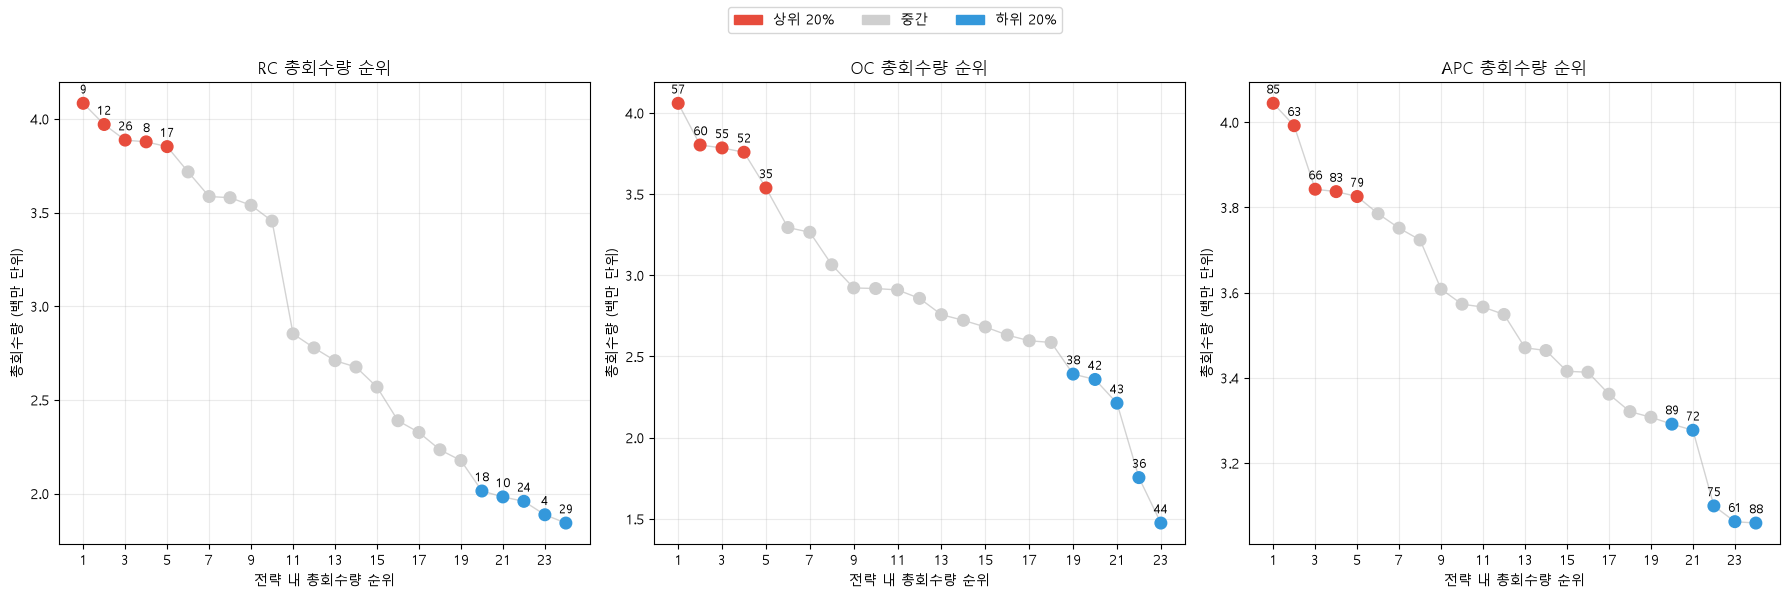

In [6]:
from matplotlib.patches import Patch

# 선정 구분별 색상
color_map = {
    '상위 20%': '#E74C3C',  # 빨간색
    '중간': '#CFCFCF',      # 회색
    '하위 20%': '#3498DB'   # 파란색
}

# RC·OC·APC 그래프를 각각 생성
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

for ax, strategy in zip(axes, target_strategies):

    # 해당 전략을 총회수량 순위대로 정렬
    plot_df = (
        ranking_df[
            ranking_df['Strategy'] == strategy
        ]
        .sort_values('총회수량_순위')
        .copy()
    )

    # 그래프에서 읽기 쉽게 백만 단위로 변환
    plot_df['총회수량_백만'] = (
        plot_df['총회수량'] / 1_000_000
    )

    # 순위에 따른 총회수량 흐름 표시
    ax.plot(
        plot_df['총회수량_순위'],
        plot_df['총회수량_백만'],
        color='lightgray',
        linewidth=1,
        zorder=1
    )

    # 상위·중간·하위 구분에 따라 점 색상 지정
    point_colors = plot_df['선정구분'].map(color_map)

    ax.scatter(
        plot_df['총회수량_순위'],
        plot_df['총회수량_백만'],
        c=point_colors,
        s=70,
        zorder=2
    )

    # 상위·하위 20% 배치에만 Batch_ID 표시
    selected_df = plot_df[
        plot_df['선정구분'] != '중간'
    ]

    for _, row in selected_df.iterrows():
        ax.annotate(
            str(int(row[batch_col])),
            (
                row['총회수량_순위'],
                row['총회수량_백만']
            ),
            xytext=(0, 7),
            textcoords='offset points',
            ha='center',
            fontsize=9
        )

    ax.set_title(f'{strategy} 총회수량 순위')
    ax.set_xlabel('전략 내 총회수량 순위')
    ax.set_ylabel('총회수량 (백만 단위)')
    ax.set_xticks(
        range(1, len(plot_df) + 1, 2)
    )
    ax.grid(alpha=0.25)

# 공통 범례
legend_items = [
    Patch(color='#E74C3C', label='상위 20%'),
    Patch(color='#CFCFCF', label='중간'),
    Patch(color='#3498DB', label='하위 20%')
]

fig.legend(
    handles=legend_items,
    loc='upper center',
    ncol=3
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### 5. 결과 해석

- 총회수량 기준 상·하위 20% 배치가 전략별로 명확하게 표시됐다.
- RC는 상위 5개가 약 385만~408만에 모여 있고, 10위 이후부터 총회수량이 크게 떨어진다.
- OC는 57번이 가장 높으며, 60·55·52번이 비슷한 수준이다. 35번 이후부터 감소 폭이 커진다.
- APC는 다른 전략보다 전체 총회수량이 높고 배치 간 차이가 작다. APC 하위 20%도 약 306만~329만으로 RC·OC의 일부 중상위 배치보다 높다.

중요한 해석

전략별 성과 수준이 다르므로 전체 배치를 섞어서 상위 20%를 선정하면 APC에 후보가 집중될 수 있다. 따라서 RC·OC·APC 내부에서 각각 후보를 선정하는 현재 방식이 전략별 운전 특성을 반영하는 데 적절하다.

다만 상위 20%는 후보 수를 일관되게 정하기 위한 규칙이다. 특히 APC는 5위와 6위 차이가 크지 않아 총회수량만으로 자연스럽게 구분되는 경계라고 보기는 어렵다. 최종 골든배치를 정하려면 최종 농도와 농도 궤적도 함께 확인해야 한다.

# 6. 상위 20% 후보의 최종 농도 순위 확인

In [7]:
# 시간순으로 정렬한 Train 데이터에서
# 배치별 최종 농도와 최대 농도 계산
batch_kpi = (
    train_df
    .sort_values([batch_col, time_col])
    .groupby([batch_col, 'Strategy'], as_index=False)
    .agg(
        총회수량=(total_col, 'first'),

        # 각 배치의 마지막 시점 페니실린 농도
        최종농도=(p_col, 'last'),

        # 전체 운전기간 중 가장 높은 페니실린 농도
        최대농도=(p_col, 'max'),

        # 배치의 최종 운전시간
        운전시간=(time_col, 'max')
    )
)

# 전략 내부에서 최종 농도의 백분위 계산
# 값이 1에 가까울수록 해당 전략에서 최종 농도가 높음
batch_kpi['최종농도_백분위'] = (
    batch_kpi
    .groupby('Strategy')['최종농도']
    .rank(pct=True)
)

# 앞에서 계산한 총회수량 순위와 선정구분을 연결
batch_kpi = batch_kpi.merge(
    ranking_df[[
        batch_col,
        'Strategy',
        '총회수량_순위',
        '선정구분'
    ]],
    on=[batch_col, 'Strategy'],
    how='left'
)

# 총회수량 상위 20% 후보만 추출
top_candidates = (
    batch_kpi[
        batch_kpi['선정구분'] == '상위 20%'
    ]
    .copy()
)

# 최종 농도 수준에 따라 후보 유형 구분
top_candidates['후보유형'] = '최종농도 중간 수준'

# 총회수량과 최종 농도가 모두 상위 20%인 경우
top_candidates.loc[
    top_candidates['최종농도_백분위'] >= 0.80,
    '후보유형'
] = '총회수량·최종농도 모두 상위 20%'

# 최종 농도가 전략 내 하위 50%보다 낮은 경우
# 50%와 정확히 같은 배치는 경계값이므로 포함하지 않음
top_candidates.loc[
    top_candidates['최종농도_백분위'] < 0.50,
    '후보유형'
] = '총회수량 상위·최종농도 하위 50%'

# 전략과 총회수량 순위대로 정렬
top_candidates = top_candidates.sort_values(
    ['Strategy', '총회수량_순위']
)

display(
    top_candidates[[
        'Strategy',
        batch_col,
        '총회수량',
        '총회수량_순위',
        '최종농도',
        '최대농도',
        '최종농도_백분위',
        '후보유형'
    ]].round(3)
)

# 후보 유형별 배치번호 요약
print('\n후보 유형별 Batch_ID')

for candidate_type, group in top_candidates.groupby('후보유형'):
    print(
        candidate_type,
        ':',
        sorted(group[batch_col].tolist())
    )

,Strategy,배치번호,총회수량,총회수량_순위,최종농도,최대농도,최종농도_백분위,후보유형
65,APC,85,4044300.0,1.0,31.898,31.898,0.917,총회수량·최종농도 모두 상위 20%
49,APC,63,3991800.0,2.0,28.677,28.739,0.458,총회수량 상위·최종농도 하위 50%
52,APC,66,3842700.0,3.0,26.655,26.691,0.167,총회수량 상위·최종농도 하위 50%
64,APC,83,3837100.0,4.0,27.214,27.214,0.250,총회수량 상위·최종농도 하위 50%
61,APC,79,3825600.0,5.0,31.531,31.546,0.875,총회수량·최종농도 모두 상위 20%
43,OC,57,4059100.0,1.0,32.518,32.518,0.957,총회수량·최종농도 모두 상위 20%
46,OC,60,3802300.0,2.0,18.818,25.136,0.435,총회수량 상위·최종농도 하위 50%
41,OC,55,3784400.0,3.0,27.268,28.272,0.783,최종농도 중간 수준
39,OC,52,3757800.0,4.0,22.300,26.519,0.522,최종농도 중간 수준
25,OC,35,3537900.0,5.0,28.302,28.302,0.870,총회수량·최종농도 모두 상위 20%



후보 유형별 Batch_ID
총회수량 상위·최종농도 하위 50% : [9, 60, 63, 66, 83]
총회수량·최종농도 모두 상위 20% : [8, 35, 57, 79, 85]
최종농도 중간 수준 : [12, 17, 26, 52, 55]


### 6. 결과 해석

총회수량 상위 20% 후보 15개가 최종 농도에 따라 정확히 세 그룹으로 나뉘었다.

1. 두 지표가 모두 높은 후보
- RC: 8
- OC: 35, 57
- APC: 79, 85

총회수량과 최종 농도가 모두 전략 내 상위 20%이므로 현재 가장 강한 골든배치 후보다.

2. 총회수량은 높지만 최종 농도가 낮은 후보
- RC: 9
- OC: 60
- APC: 63, 66, 83

다만 이 다섯 배치를 같은 유형의 이상으로 해석하면 안 된다.

- 9·60번은 최대농도보다 최종농도가 크게 낮아 후반부 농도 하락이 의심된다.
- 63·66·83번은 최대농도와 최종농도가 거의 같아 후반부 하락은 없다. 다만 APC 안에서 농도 수준이 상대적으로 낮다.

즉, 9·60번은 후반부 성능 저하형, 63·66·83번은 상대적 저농도형에 가까울 가능성이 있다.

3. 최종 농도가 중간 수준인 후보
- RC: 12, 17, 26
- OC: 52, 55

12·26번은 최종 농도 백분위가 각각 0.792와 0.750으로 상위 20% 기준에 근접한다. 단순히 0.8 미만이라는 이유로 제외하면 안 된다.

또한 52번은 최대농도 26.519에서 최종농도 22.300으로 감소해 추가 확인이 필요하다.

최종 농도 백분위는 각 전략 안에서의 상대적인 순위다. 따라서 최종 농도 하위 50%라는 표현이 곧 절대적으로 낮은 농도나 공정 이상을 의미하지는 않는다.

## 확인된 내용 정리
1. Train/Test 분할 검증 완료: GroupShuffleSplit으로 배치 단위 80/20 분할, 중복 없음 확인 (Train: RC24/OC23/APC24/Fault9)
2. 전략별 상위 20% 후보가 3개 그룹으로 자연스럽게 나뉨 (총회수량 vs 최종농도 교차분석):
- 총회수량·최종농도 모두 상위: RC 8, OC 35·57, APC 79·85 (5개 → 가장 강한 골든배치 후보)
- 총회수량 상위·최종농도 하위: RC 9, OC 60, APC 63·66·83 (기존 "이상후보"와 동일)
- 최종농도 중간 수준: RC 12·17·26, OC 52·55 (0.8 문턱값 근처라 성급히 제외하면 안 된다고 명시)
3. "이상후보" 내부에서도 유형이 갈린다는 걸 정량적으로 재확인: 9·60번(최대농도 대비 최종농도 급락 = 후반부 저하형) vs 63·66·83번(최대≈최종 = 상대적 저농도형) — 저희가 그래프로 확인했던 것과 정확히 일치

# 1. P(t) 궤적 오버레이 — 이상후보 vs 대조군

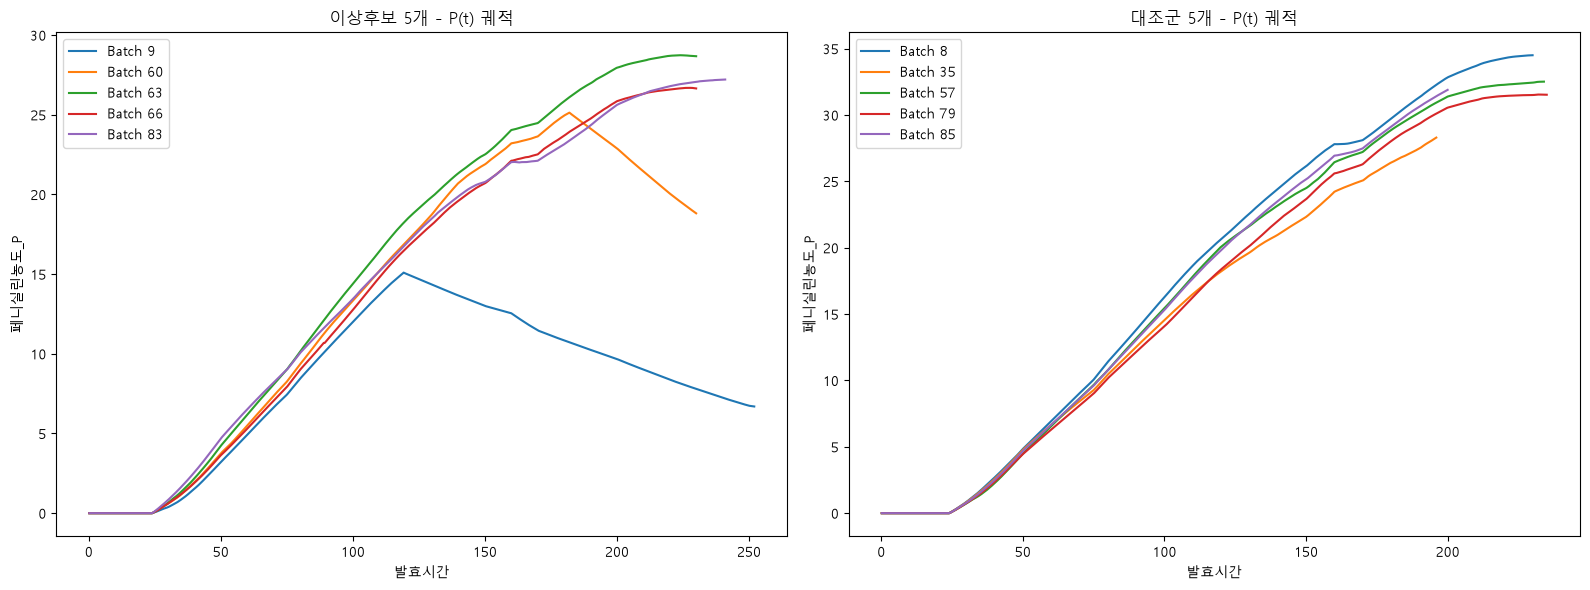

In [8]:
# 확정된 배치 목록
# - 이상후보: 총회수량은 상위20%인데 최종농도는 하위50%인 배치 (지표 불일치)
# - 대조군: 총회수량, 최종농도 둘 다 상위20%인 배치 (지표 일치, 정상 비교기준)
anomaly = [9, 60, 63, 66, 83]
control = [8, 35, 57, 79, 85]

# 그래프 두 개를 나란히 그릴 도화지 준비 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 왼쪽 그래프: 이상후보 5개 배치의 시간에 따른 P(농도) 변화 ---
for b in anomaly:
    sub = df[df[batch_col]==b]  # 해당 배치번호 데이터만 추출
    axes[0].plot(sub[time_col], sub[p_col], label=f'Batch {b}')  # 시간(x) vs 농도(y) 선그래프
axes[0].set_title('이상후보 5개 - P(t) 궤적')
axes[0].set_xlabel(time_col); axes[0].set_ylabel(p_col)
axes[0].legend()  # 범례(어떤 색이 몇 번 배치인지) 표시

# --- 오른쪽 그래프: 대조군 5개 배치도 동일한 방식으로 ---
for b in control:
    sub = df[df[batch_col]==b]
    axes[1].plot(sub[time_col], sub[p_col], label=f'Batch {b}')
axes[1].set_title('대조군 5개 - P(t) 궤적')
axes[1].set_xlabel(time_col); axes[1].set_ylabel(p_col)
axes[1].legend()

plt.tight_layout()  # 그래프 간 간격 자동 조정(겹침 방지)
plt.show()

# 9번·60번 후반부 농도 저하 원인 확인 — 정점 시점의 기질농도(S) 비교

"9번·60번 배치는 발효 후반부에 미생물이 기질(당)을 더 이상 소비하지 못하게 되면서, 기질이 소모되지 않고 쌓이고(축적), 그 결과 페니실린 생산도 멈추거나 오히려 줄어드는 것 아닐까?"

In [9]:
# (63·66·83번은 후반부 하락이 없으므로 이번 분석 대상에서 제외)

decline_batches = [9, 60]

for b in decline_batches:
    sub = df[df[batch_col] == b].reset_index(drop=True)

    # 페니실린 농도가 가장 높았던 시점(정점)을 찾음
    peak_idx = sub[p_col].idxmax()
    peak_time = sub.loc[peak_idx, time_col]
    peak_p = sub.loc[peak_idx, p_col]
    final_p = sub[p_col].iloc[-1]

    # 정점 시점의 기질농도, 배치 종료 시점의 기질농도
    s_at_peak = sub.loc[peak_idx, s_col]
    s_at_end = sub[s_col].iloc[-1]

    print(f'=== Batch {b} ===')
    print(f'정점 시점: {peak_time}h, 정점 농도: {peak_p:.2f} g/L, 최종 농도: {final_p:.2f} g/L')
    print(f'정점 시점 기질농도(S): {s_at_peak:.3f} g/L')
    print(f'종료 시점 기질농도(S): {s_at_end:.3f} g/L')
    print(f'기질농도 변화량(종료-정점): {s_at_end - s_at_peak:+.3f} g/L')
    print()

=== Batch 9 ===
정점 시점: 119.2h, 정점 농도: 15.10 g/L, 최종 농도: 6.70 g/L
정점 시점 기질농도(S): 0.006 g/L
종료 시점 기질농도(S): 83.956 g/L
기질농도 변화량(종료-정점): +83.950 g/L

=== Batch 60 ===
정점 시점: 182.0h, 정점 농도: 25.14 g/L, 최종 농도: 18.82 g/L
정점 시점 기질농도(S): 0.020 g/L
종료 시점 기질농도(S): 21.913 g/L
기질농도 변화량(종료-정점): +21.893 g/L



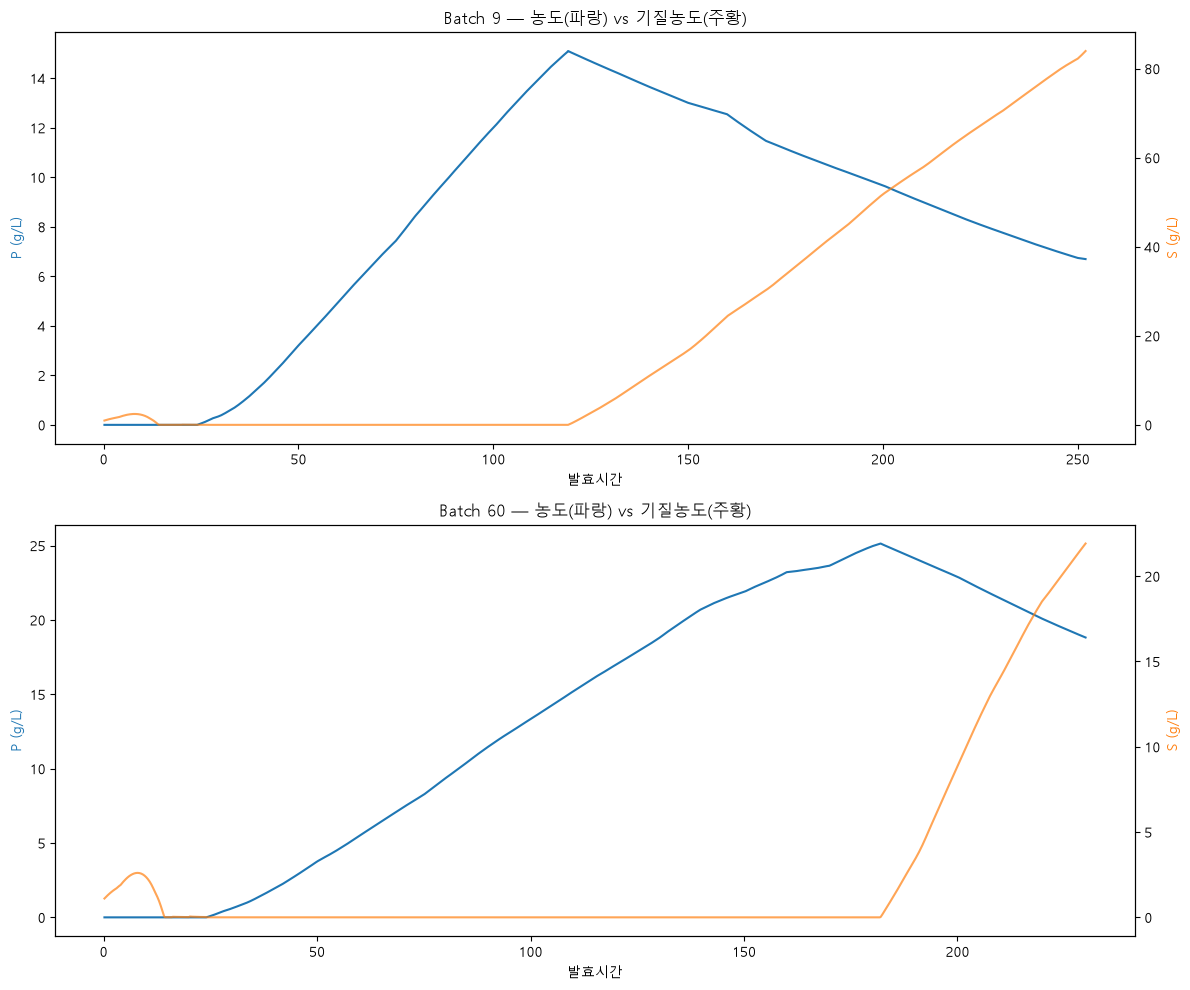

In [10]:
# 정점 이후 구간에서 농도(P)와 기질농도(S)가 함께 어떻게 움직이는지 확인
fig, axes = plt.subplots(len(decline_batches), 1, figsize=(12, 5 * len(decline_batches)))

for i, b in enumerate(decline_batches):
    sub = df[df[batch_col] == b]
    ax = axes[i]

    ax.plot(sub[time_col], sub[p_col], color='tab:blue', label='P (페니실린농도)')
    ax.set_xlabel(time_col)
    ax.set_ylabel('P (g/L)', color='tab:blue')

    ax2 = ax.twinx()
    ax2.plot(sub[time_col], sub[s_col], color='tab:orange', alpha=0.7, label='S (기질농도)')
    ax2.set_ylabel('S (g/L)', color='tab:orange')

    ax.set_title(f'Batch {b} — 농도(파랑) vs 기질농도(주황)')

plt.tight_layout()
plt.show()

### 9번·60번 후반부 농도 저하 원인 — 기질 축적 확인

- **Batch 9**: 정점(119.2h) 시점 기질농도는 0.006 g/L(거의 소진)였는데, 종료 시점엔 83.956 g/L까지 치솟음
- **Batch 60**: 정점(182.0h) 시점 기질농도 0.020 g/L → 종료 시점 21.913 g/L
- 그래프를 보면 **두 배치 모두 P(농도)가 정점을 찍는 바로 그 시점 부근에서 S(기질농도)가 거의 동시에 바닥에서 치솟기 시작**함
- 정점 이전까지는 기질이 거의 0에 가깝게 유지되며(정상적으로 소비되고 있었다는 뜻) 농도가 꾸준히 상승하다가, 정점 이후 기질이 안 먹히고 쌓이면서 농도가 하락하는 패턴이 뚜렷함

**해석 (상관관계 수준으로 표현)**
- 이 두 배치는 **"미생물이 기질을 더 이상 소비하지 못하게 된 시점부터 페니실린 생산이 멈추고 오히려 감소한다"**는 패턴을 보임
- 이건 저희가 이전에 확인했던 Fault 그룹의 특징(기질 축적 + 대사활성 저하)과 **동일한 유형의 현상이 정상 라벨(RC 9번, OC 60번) 배치에서도 나타난 것**으로 보임
- 다만 이게 정확히 "왜" 발생했는지(미생물 자체의 문제인지, 다른 조작변수 이상 때문인지)는 이 분석만으로는 알 수 없어서, "기질 축적과 농도 하락이 같은 시점에 함께 관찰됐다" 정도로 표현하는 게 안전함

# 3. 정점 전후 OUR·DO2 변화 확인

In [11]:
# 9번·60번 정점 전후 OUR(산소소비율), DO2(용존산소) 변화 확인
# Fault 그룹의 특징(기질 증가 + OUR 감소 + DO2 증가 + P 감소)과 같은 패턴인지 검증

our_col = '산소소비율_OUR'
do2_col = '용존산소_DO2'

for b in decline_batches:
    sub = df[df[batch_col] == b].reset_index(drop=True)
    peak_idx = sub[p_col].idxmax()
    peak_time = sub.loc[peak_idx, time_col]

    before = sub[sub[time_col] < peak_time]
    after = sub[sub[time_col] >= peak_time]

    print(f'=== Batch {b} (정점: {peak_time}h) ===')
    print(f'OUR  — 정점 이전: {before[our_col].mean():.3f} → 정점 이후: {after[our_col].mean():.3f} (변화: {after[our_col].mean()-before[our_col].mean():+.3f})')
    print(f'DO2  — 정점 이전: {before[do2_col].mean():.3f} → 정점 이후: {after[do2_col].mean():.3f} (변화: {after[do2_col].mean()-before[do2_col].mean():+.3f})')
    print()

=== Batch 9 (정점: 119.2h) ===
OUR  — 정점 이전: 1.265 → 정점 이후: 0.618 (변화: -0.647)
DO2  — 정점 이전: 13.051 → 정점 이후: 13.382 (변화: +0.331)

=== Batch 60 (정점: 182.0h) ===
OUR  — 정점 이전: 1.397 → 정점 이후: 0.625 (변화: -0.772)
DO2  — 정점 이전: 11.023 → 정점 이후: 11.765 (변화: +0.742)



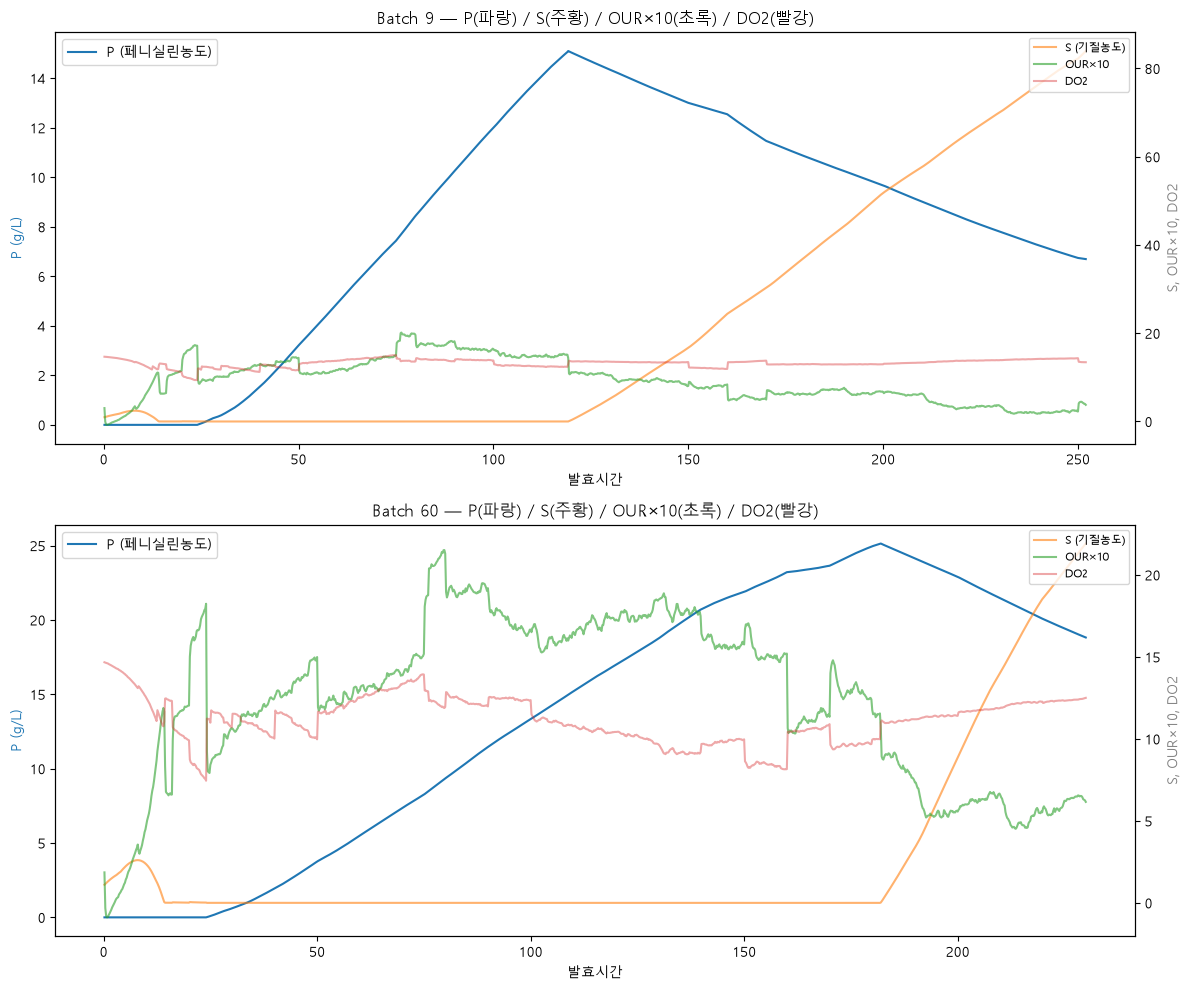

In [12]:
# P, S, OUR, DO2 네 개 한 그래프에서 같이 보기

fig, axes = plt.subplots(len(decline_batches), 1, figsize=(12, 5 * len(decline_batches)))

for i, b in enumerate(decline_batches):
    sub = df[df[batch_col] == b]
    ax = axes[i]

    ax.plot(sub[time_col], sub[p_col], color='tab:blue', label='P (페니실린농도)')
    ax.set_ylabel('P (g/L)', color='tab:blue')
    ax.set_xlabel(time_col)

    ax2 = ax.twinx()
    ax2.plot(sub[time_col], sub[s_col], color='tab:orange', alpha=0.6, label='S (기질농도)')
    ax2.plot(sub[time_col], sub[our_col] * 10, color='tab:green', alpha=0.6, label='OUR×10')
    ax2.plot(sub[time_col], sub[do2_col], color='tab:red', alpha=0.4, label='DO2')
    ax2.set_ylabel('S, OUR×10, DO2', color='gray')

    ax.set_title(f'Batch {b} — P(파랑) / S(주황) / OUR×10(초록) / DO2(빨강)')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

### 9번·60번 — Fault 그룹과 동일한 4가지 패턴 확인 완료

정점(농도 최고점) 전후로 비교한 결과:

| 변수 | Batch 9 | Batch 60 | Fault 그룹 특징 | 일치 여부 |
|---|---|---|---|---|
| 기질농도(S) | 0.006→83.956 (급증) | 0.020→21.913 (급증) | 증가 | ✅ |
| OUR(산소소비율) | 1.265→0.618 (-0.647) | 1.397→0.625 (-0.772) | 감소 | ✅ |
| DO2(용존산소) | 13.051→13.382 (+0.331) | 11.023→11.765 (+0.742) | 증가 | ✅ |
| P(페니실린농도) | 정점 이후 하락 | 정점 이후 하락 | 감소 | ✅ |

**4가지 지표 모두 Fault 그룹의 패턴과 동일한 방향으로 확인됨**

**해석 (여전히 상관관계 수준으로)**
- 정점 시점을 기준으로 산소소비율(OUR)이 뚜렷하게 감소하고(초록선이 정점 부근에서 꺾여 내려감), 동시에 기질농도(S)가 축적되기 시작함
- 이는 "미생물의 대사활동(산소 소비)이 둔화되면서, 기질을 더 이상 소비하지 못하고 쌓이며, 그 결과 산소도 덜 소비되어 DO2가 오르고, 페니실린 생산도 멈추는" 하나의 연결된 흐름으로 해석 가능
- **결론**: RC 9번, OC 60번은 라벨상 정상(Fault=0)이지만, 실제 운전 양상은 Fault 그룹에서 관찰되는 대사활성 저하 패턴과 상관관계 수준에서 일치함
- 다만 이것이 "왜" 일어났는지(장비 이상, 오염, 다른 조작변수 문제 등 근본 원인)는 이 데이터만으로 규명할 수 없으므로, "동일한 패턴이 관찰됐다"까지만 표현하고 원인을 단정하지 않음

# 이것이 왜 중요한 발견인가?
이 결과는 어제 정리한 마스터 문서의 **이진 Fault 라벨만으로 모든 공정 이상 패턴을 설명하기 어렵다**는 주장(Batch 10·30 사례)에 RC 9번·OC 60번이라는 새로운 실증 사례를 하나 더 추가하는 것.

즉:

Fault=1인데 우수한 배치가 있다 (93·97번)
Fault=0인데 Fault와 똑같은 대사이상 패턴을 보이는 배치가 있다 (9번·60번) ← 방금 확인한 것

이 두 방향의 불일치를 모두 손에 쥐게 된 셈이라, "왜 골든배치·이탈점수 같은 연속적 지표가 필요한가"에 대한 근거가 훨씬 탄탄해짐

In [13]:
# Fault 배치 전체를 총회수량 기준으로 순위 확인 (Train 기준)
fault_summary = (
    train_df[train_df[strategy_col] == 'Fault']
    .groupby(batch_col, as_index=False)
    .agg(총회수량=(total_col, 'first'))
    .sort_values('총회수량', ascending=False)
    .reset_index(drop=True)
)
fault_summary['순위'] = fault_summary.index + 1

print(fault_summary)

   배치번호       총회수량  순위
0    93  4447700.0   1
1    97  3894300.0   2
2    96  3595000.0   3
3    94  3584100.0   4
4    95  1954500.0   5
5    92  1752600.0   6
6    98  1730600.0   7
7   100  1555000.0   8
8    99   890830.0   9


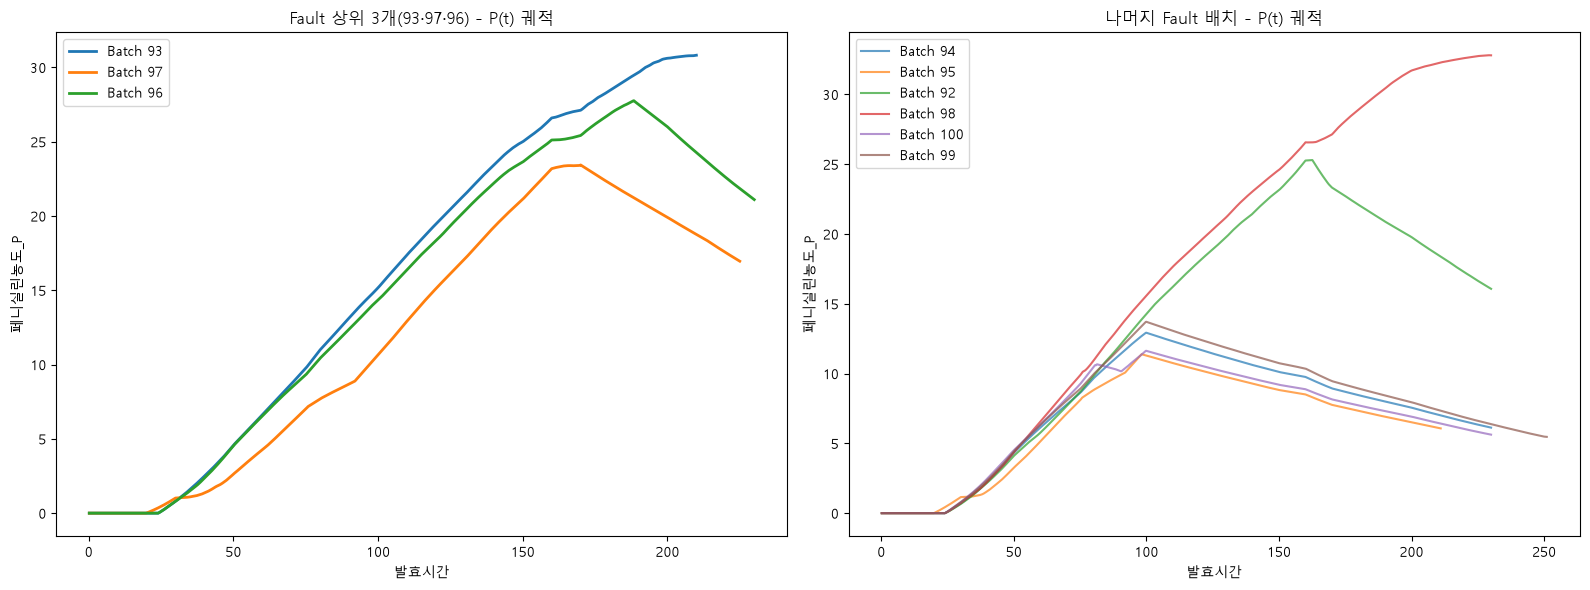

In [14]:
# Fault 배치 상위 3개(고수율) vs 하위 배치들의 P(t) 궤적 비교
fault_top = [93, 97, 96]
fault_others = [b for b in fault_summary[batch_col] if b not in fault_top]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for b in fault_top:
    sub = df[df[batch_col] == b]
    axes[0].plot(sub[time_col], sub[p_col], label=f'Batch {b}', linewidth=2)
axes[0].set_title('Fault 상위 3개(93·97·96) - P(t) 궤적')
axes[0].set_xlabel(time_col); axes[0].set_ylabel(p_col)
axes[0].legend()

for b in fault_others:
    sub = df[df[batch_col] == b]
    axes[1].plot(sub[time_col], sub[p_col], label=f'Batch {b}', alpha=0.7)
axes[1].set_title('나머지 Fault 배치 - P(t) 궤적')
axes[1].set_xlabel(time_col); axes[1].set_ylabel(p_col)
axes[1].legend()

plt.tight_layout()
plt.show()

### Fault 배치 총회수량 순위 및 궤적 확인

**Train 내 순위 (91번은 Test로 빠져서 9개만 있음)**
93(1위, 444.8만) → 97(2위, 389.4만) → 96(3위, 359.5만) → 94(4위, 358.4만, 3위와 거의 차이 없음) → 95(5위) → 92(6위) → 98(7위) → 100(8위) → 99(9위)

**궤적 패턴**
- **93·97·96 (상위 3개)**: 완만하게 상승해서 25~31 g/L 수준에서 정체되거나 소폭 하락. 대체로 안정적인 "정상적 고수율" 모양
- **92 (하위권인데 궤적은 특이)**: 90~100h 근처에서 25까지 올라갔다가 160h 이후 뚜렷하게 꺾여 230h 시점엔 16까지 하락 — **정점 후 급락 패턴(RC 9번·OC 60번과 동일 유형)**
- **98**: 90h부터 230h까지 계속 우상향하며 그래프 끝(약 32)이 최고점 — 하락 없이 꾸준히 상승하는 유형. 총회수량은 낮지만(7위) 농도 궤적만 보면 63·66·83번처럼 안정적으로 우상향하는 축에 가까움
- **94·95·99·100**: 처음부터 쭉 낮은 수준(10~14)에서 큰 변화 없이 유지 — 정점 후 하락이 아니라 "애초에 낮게 시작해서 낮게 끝나는" 다른 유형

In [15]:
# Fault 9개 배치 전체에 대해 '정점 후 급락 여부'를 숫자로 판정
fault_batches = fault_summary[batch_col].tolist()

print(f"{'배치':>6} | {'정점농도':>8} | {'최종농도':>8} | {'하락폭':>8} | {'하락률(%)':>8}")
for b in fault_batches:
    sub = df[df[batch_col] == b]
    peak_p = sub[p_col].max()
    final_p = sub[p_col].iloc[-1]
    drop = peak_p - final_p
    drop_pct = drop / peak_p * 100
    print(f"{b:>6} | {peak_p:>8.2f} | {final_p:>8.2f} | {drop:>8.2f} | {drop_pct:>8.1f}")

    배치 |     정점농도 |     최종농도 |      하락폭 |   하락률(%)
    93 |    30.82 |    30.82 |     0.00 |      0.0
    97 |    23.44 |    16.96 |     6.48 |     27.6
    96 |    27.76 |    21.10 |     6.66 |     24.0
    94 |    12.93 |     6.13 |     6.80 |     52.6
    95 |    11.39 |     6.07 |     5.31 |     46.7
    92 |    25.30 |    16.07 |     9.23 |     36.5
    98 |    32.81 |    32.80 |     0.01 |      0.0
   100 |    11.63 |     5.63 |     6.01 |     51.6
    99 |    13.71 |     5.47 |     8.24 |     60.1


# Fault 서브타입별 하락률 비교

In [16]:
# 이전에 확인한 Fault 서브타입 그룹과 하락률을 교차 확인
group_A_fg = [94, 95, 97, 99, 100]   # 공기주입(Fg) 변화 그룹
group_B_fbfc = [92, 93, 96, 98]      # 염기·냉각(Fb·Fc) 변화 그룹

decline_data = {
    93: 0.0, 97: 27.6, 96: 24.0, 94: 52.6, 95: 46.7,
    92: 36.5, 98: 0.0, 100: 51.6, 99: 60.1
}

print("=== Group A (Fg 변화) 하락률 ===")
for b in group_A_fg:
    print(f"  Batch {b}: {decline_data[b]:.1f}%")
group_a_mean = sum(decline_data[b] for b in group_A_fg) / len(group_A_fg)
print(f"  평균: {group_a_mean:.1f}%")

print("\n=== Group B (Fb·Fc 변화) 하락률 ===")
for b in group_B_fbfc:
    print(f"  Batch {b}: {decline_data[b]:.1f}%")
group_b_mean = sum(decline_data[b] for b in group_B_fbfc) / len(group_B_fbfc)
print(f"  평균: {group_b_mean:.1f}%")

=== Group A (Fg 변화) 하락률 ===
  Batch 94: 52.6%
  Batch 95: 46.7%
  Batch 97: 27.6%
  Batch 99: 60.1%
  Batch 100: 51.6%
  평균: 47.7%

=== Group B (Fb·Fc 변화) 하락률 ===
  Batch 92: 36.5%
  Batch 93: 0.0%
  Batch 96: 24.0%
  Batch 98: 0.0%
  평균: 15.1%


### 가장 심하게 하락한 99번(60.1%)도 9·60번과 같은 기질축적 메커니즘인지 확인

In [17]:
# 하락률이 가장 큰 99번에 대해 9번·60번과 동일한 분석 적용
check_batch = 99
sub = df[df[batch_col] == check_batch].reset_index(drop=True)
peak_idx = sub[p_col].idxmax()
peak_time = sub.loc[peak_idx, time_col]

before = sub[sub[time_col] < peak_time]
after = sub[sub[time_col] >= peak_time]

print(f"=== Batch {check_batch} (정점: {peak_time}h) ===")
print(f"S(기질농도)  — 정점 이전: {before[s_col].mean():.3f} → 정점 이후: {after[s_col].mean():.3f}")
print(f"OUR         — 정점 이전: {before[our_col].mean():.3f} → 정점 이후: {after[our_col].mean():.3f}")
print(f"DO2         — 정점 이전: {before[do2_col].mean():.3f} → 정점 이후: {after[do2_col].mean():.3f}")

=== Batch 99 (정점: 99.8h) ===
S(기질농도)  — 정점 이전: 0.184 → 정점 이후: 52.858
OUR         — 정점 이전: 1.273 → 정점 이후: 0.578
DO2         — 정점 이전: 12.495 → 정점 이후: 13.183


### Fault 서브타입별 하락률 비교 — 명확한 차이 확인

| 그룹 | 평균 하락률 | 배치별 범위 |
|---|---|---|
| Group A (Fg 변화, 91·94·95·97·99·100) | **47.7%** | 27.6% ~ 60.1% |
| Group B (Fb·Fc 변화, 92·93·96·98) | **15.1%** | 0.0% ~ 36.5% |

**Group A가 Group B보다 평균 3배 이상 심하게 무너집니다.** 이건 단순히 "결함 발생 시점에 어떤 조작변수가 바뀌었는지"의 차이를 넘어서, **결과(농도 하락 정도)까지 뚜렷하게 갈린다**는 뜻입니다. 즉 공기주입(Fg) 관련 결함이 염기·냉각(Fb·Fc) 관련 결함보다 페니실린 생산에 훨씬 치명적이라고 해석할 수 있습니다.

### Batch 99 — 9번·60번과 동일한 메커니즘 확인

| 변수 | 정점 이전 | 정점 이후 | 방향 |
|---|---|---|---|
| S(기질농도) | 0.184 | 52.858 | 급증 |
| OUR(산소소비율) | 1.273 | 0.578 | 감소 |
| DO2(용존산소) | 12.495 | 13.183 | 증가 |

**RC 9번, OC 60번, Fault 92번에 이어 Fault 99번도 정확히 같은 3종 세트(S↑ OUR↓ DO2↑)를 보입니다.** 그리고 99번은 하락률이 60.1%로 지금까지 확인한 배치 중 가장 심합니다.


# Group A 전체(94·95·100)와 Group B 전체(92·96·98)를 한 번에 검증

In [18]:
# Group A(94,95,100)와 Group B(92,96,98) 나머지 배치들도 같은 3종 세트 확인
# (93,97,99는 이미 확인했으므로 제외)
remaining = {94: 'A', 95: 'A', 100: 'A', 92: 'B', 96: 'B', 98: 'B'}

print(f"{'배치':>6} {'그룹':>5} | {'S 이전':>8} {'S 이후':>8} | {'OUR 이전':>9} {'OUR 이후':>9} | {'DO2 이전':>9} {'DO2 이후':>9}")
for b, grp in remaining.items():
    sub = df[df[batch_col] == b].reset_index(drop=True)
    peak_idx = sub[p_col].idxmax()
    peak_time = sub.loc[peak_idx, time_col]
    before = sub[sub[time_col] < peak_time]
    after = sub[sub[time_col] >= peak_time]
    print(f"{b:>6} {grp:>5} | {before[s_col].mean():>8.3f} {after[s_col].mean():>8.3f} | "
          f"{before[our_col].mean():>9.3f} {after[our_col].mean():>9.3f} | "
          f"{before[do2_col].mean():>9.3f} {after[do2_col].mean():>9.3f}")

    배치    그룹 |     S 이전     S 이후 |    OUR 이전    OUR 이후 |    DO2 이전    DO2 이후
    94     A |    0.208   34.141 |     1.232     0.597 |    13.786    14.429
    95     A |    0.171   41.509 |     0.875     0.469 |    14.167    14.806
   100     A |    0.469   41.134 |     1.335     0.822 |    12.733    12.738
    92     B |    0.139   24.223 |     1.400     0.815 |    13.179    13.685
    96     B |    0.161   14.307 |     1.319     0.669 |    12.101    12.838
    98     B |    0.155    0.001 |     1.270     0.894 |    12.776    13.024


### Fault 배치 분석 최종 결론 (Fault 포함 여부 의사결정용)

**핵심 발견**
Fault 9개 배치 중 7개(92·94·95·96·97·99·100)는 정도의 차이만 있을 뿐 공통적으로
"정점 이후 기질 축적 → 대사활성(OUR) 저하 → 농도 하락"이라는 동일한 패턴을 보인다.
이 패턴에서 완전히 벗어난 배치는 93번과 98번, 단 2개뿐이다.

**하락 강도 스펙트럼**
- 안정적(하락 0%): 93, 98
- 경미한 하락(24~37%): 96, 92
- 중간 하락(28%): 97
- 심각한 하락(47~60%): 94, 95, 99, 100

**같은 메커니즘이 정상 라벨 배치에서도 발견됨**
RC 9번, OC 60번에서도 동일한 패턴(기질축적+OUR감소)이 확인되어,
이진 Fault 라벨이 실제 공정 이상을 완전히 설명하지 못한다는 근거가 보강됨.

**골든배치 설계에 대한 제안**
- 93·98번만 "고성과 Fault 참고 프로파일" 후보로 고려 가능 (다만 표본 2개로 매우 적음)
- 96·97번은 총회수량은 높지만 농도 궤적이 흔들리므로, 골든배치 기준으로 쓰기엔 부적합
- → 트랙3 의사결정 시 "Fault 제외" 쪽에 무게가 실리는 근거 자료로 활용 권장

# 중간 그룹 5개 궤적 확인

    배치 |     정점농도 |     최종농도 |    하락률(%)
    12 |    30.10 |    30.10 |       0.0
    17 |    26.99 |    26.99 |       0.0
    26 |    30.15 |    30.10 |       0.2
    52 |    26.52 |    22.30 |      15.9
    55 |    28.27 |    27.27 |       3.6


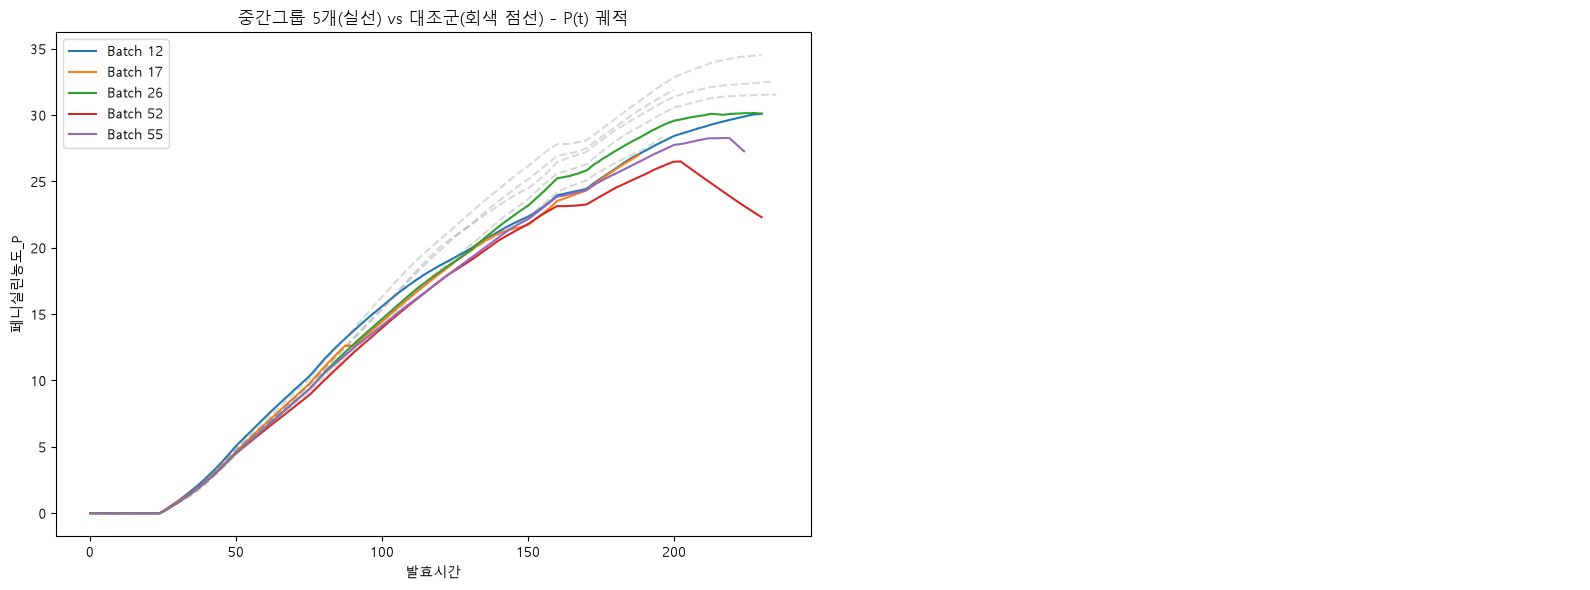

In [19]:
# 아직 확인 안 한 "중간 수준" 그룹 — 골든배치 확정 전 마지막 점검
middle = [12, 17, 26, 52, 55]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 중간그룹 vs 대조군(비교 기준선으로 회색 점선 추가)
for b in middle:
    sub = df[df[batch_col] == b]
    axes[0].plot(sub[time_col], sub[p_col], label=f'Batch {b}')
for b in control:
    sub = df[df[batch_col] == b]
    axes[0].plot(sub[time_col], sub[p_col], color='gray', alpha=0.3, linestyle='--')
axes[0].set_title('중간그룹 5개(실선) vs 대조군(회색 점선) - P(t) 궤적')
axes[0].set_xlabel(time_col); axes[0].set_ylabel(p_col)
axes[0].legend()

# 오른쪽: 정점농도 대비 최종농도 하락률 정량 확인 (9·60·92·99 분석과 동일한 방식)
print(f"{'배치':>6} | {'정점농도':>8} | {'최종농도':>8} | {'하락률(%)':>9}")
for b in middle:
    sub = df[df[batch_col] == b]
    peak = sub[p_col].max()
    final = sub[p_col].iloc[-1]
    drop_pct = (peak - final) / peak * 100
    print(f"{b:>6} | {peak:>8.2f} | {final:>8.2f} | {drop_pct:>9.1f}")

axes[1].axis('off')
plt.tight_layout()
plt.show()

# 7. 최종 골든배치 리스트 확정

## 중간그룹 5개 추가 검증 (12·17·26·52·55)

기존에 "중간 수준"으로만 분류되고 궤적을 확인하지 않았던 5개 배치를, 9·60번과 같은 방식(정점농도 대비 최종농도 하락률)으로 검증했다.

| 배치 | 정점농도 | 최종농도 | 하락률(%) |
|---|---|---|---|
| 12 | 30.10 | 30.10 | 0.0 |
| 17 | 26.99 | 26.99 | 0.0 |
| 26 | 30.15 | 30.10 | 0.2 |
| 55 | 28.27 | 27.27 | 3.6 |
| 52 | 26.52 | 22.30 | **15.9** |

**해석**

- 12·17·26·55번은 하락률이 0~3.6%로, 대조군(8·35·57·79·85)과 사실상 동일한 수준으로 안정적이다.
- 이 배치들이 "중간 수준"으로 분류됐던 이유는 운전이 불안정해서가 아니라, 총회수량 순위가 전략 내 상위 20% 문턱값을 살짝 넘지 못했기 때문이다.
- 52번만 하락률 15.9%로 뚜렷이 구분된다. Fault 92번(36.5%)·96번(24.0%)과 비슷한 중간 수준의 하락이며, 팀 논의를 거쳐 포함 여부를 확정할 필요가 있다.

## 최종 골든배치 판정 기준 및 결과

| 판정 | 배치 | 근거 |
|---|---|---|
| 포함 (핵심) | RC 8 / OC 35·57 / APC 79·85 | 총회수량·최종농도 모두 상위 20%, 하락 없음 |
| 포함 (추가) | RC 12·17·26 / OC 55 | 총회수량 순위만 낮았을 뿐 궤적은 핵심 그룹과 동일하게 안정적(하락 0~3.6%) |
| 논의 필요 | OC 52 | 하락률 15.9%로 다른 포함 배치들과 뚜렷이 구분됨 |
| 제외 (확정) | RC 9 / OC 60 | 후반부 기질 축적 + 대사활성 저하로 실제 농도 하락 확인 (2번·3번 분석 참고) |
| 제외 (확정) | APC 63·66·83 | 하락은 없으나 APC 그룹 내에서 농도 수준 자체가 상대적으로 낮음 |
| 제외 (확정) | Fault 전체 | 9개 중 7개(92·94·95·96·97·99·100)가 동일한 기질축적 메커니즘을 보임 (93·98만 예외) — 표본 부족으로 별도 판단 보류 |

## 최종 추천 골든배치 (9개, 52번 제외 잠정안)

- RC: 8, 12, 17, 26
- OC: 35, 55, 57
- APC: 79, 85

전략별 각각 골든배치를 생성하며(RC/OC/APC 통합하지 않음), 52번(OC)은 팀 논의 후 포함 여부를 결정한다.

# 최종 확정 배치 + 11개 변수

In [20]:
# 최종 확정 골든배치
golden_batches = {
    'RC': [8, 12, 17, 26],
    'OC': [35, 55, 57],
    'APC': [79, 85]
}

# 12개 변수 
# - 자연변동 변수(연속형): PCHIP 보간
# - 레시피 고정 변수(계단형): 이전값유지 보간
continuous_cols = [p_col, s_col, '용존산소_DO2', 'pH', '발효온도_T', '산소소비율_OUR',
                    '염기투입유량_Fb', '냉난방수유량_Fc']
step_cols = ['공기주입유량_Fg', '당공급유량_Fs', '산투입유량_Fa', 'PAA투입유량_Fpaa']

feature_cols = continuous_cols + step_cols
print(f"총 {len(feature_cols)}개 변수 사용")
print(f"골든배치: RC {len(golden_batches['RC'])}개, OC {len(golden_batches['OC'])}개, APC {len(golden_batches['APC'])}개 (총 {sum(len(v) for v in golden_batches.values())}개)")

총 12개 변수 사용
골든배치: RC 4개, OC 3개, APC 2개 (총 9개)


In [46]:
from scipy.interpolate import PchipInterpolator, interp1d

def build_golden_band(df, batch_list, continuous_cols, step_cols, time_col, n_points=101):
    """
    - continuous_cols: 자연변동 변수 -> PCHIP 보간 (부드러운 곡선, 오버슈트 방지)
    - step_cols: 레시피 고정 변수 -> 이전값유지 보간 (계단 모양 그대로 보존)
    """
    common_points = np.linspace(0, 1, n_points)
    result = {}

    all_cols = continuous_cols + step_cols
    for col in all_cols:
        values = []
        for b in batch_list:
            sub = df[df[batch_col] == b].sort_values(time_col)
            progress = sub[time_col] / sub[time_col].max()  # 공정진행률 (사후분석이라 최종시간 기준 사용 가능)

            if col in continuous_cols:
                interpolator = PchipInterpolator(progress, sub[col])
                interpolated = interpolator(common_points)
            else:
                interpolator = interp1d(progress, sub[col], kind='previous',
                                         bounds_error=False, fill_value=(sub[col].iloc[0], sub[col].iloc[-1]))
                interpolated = interpolator(common_points)

            values.append(interpolated)

        values = np.array(values)
        result[f'{col}_mean'] = values.mean(axis=0)
        result[f'{col}_std'] = values.std(axis=0)

    band = pd.DataFrame(result, index=common_points)
    band.index.name = '공정진행률'
    return band.reset_index()

# 전략별로 각각 생성
bands = {}
for strategy, batches in golden_batches.items():
    bands[strategy] = build_golden_band(df, batches, continuous_cols, step_cols, time_col)
    print(f"{strategy} 골든배치 생성 완료: {batches}")

RC 골든배치 생성 완료: [8, 12, 17, 26, 14, 16]
OC 골든배치 생성 완료: [35, 57, 48]
APC 골든배치 생성 완료: [79, 85, 65, 62, 82, 68]


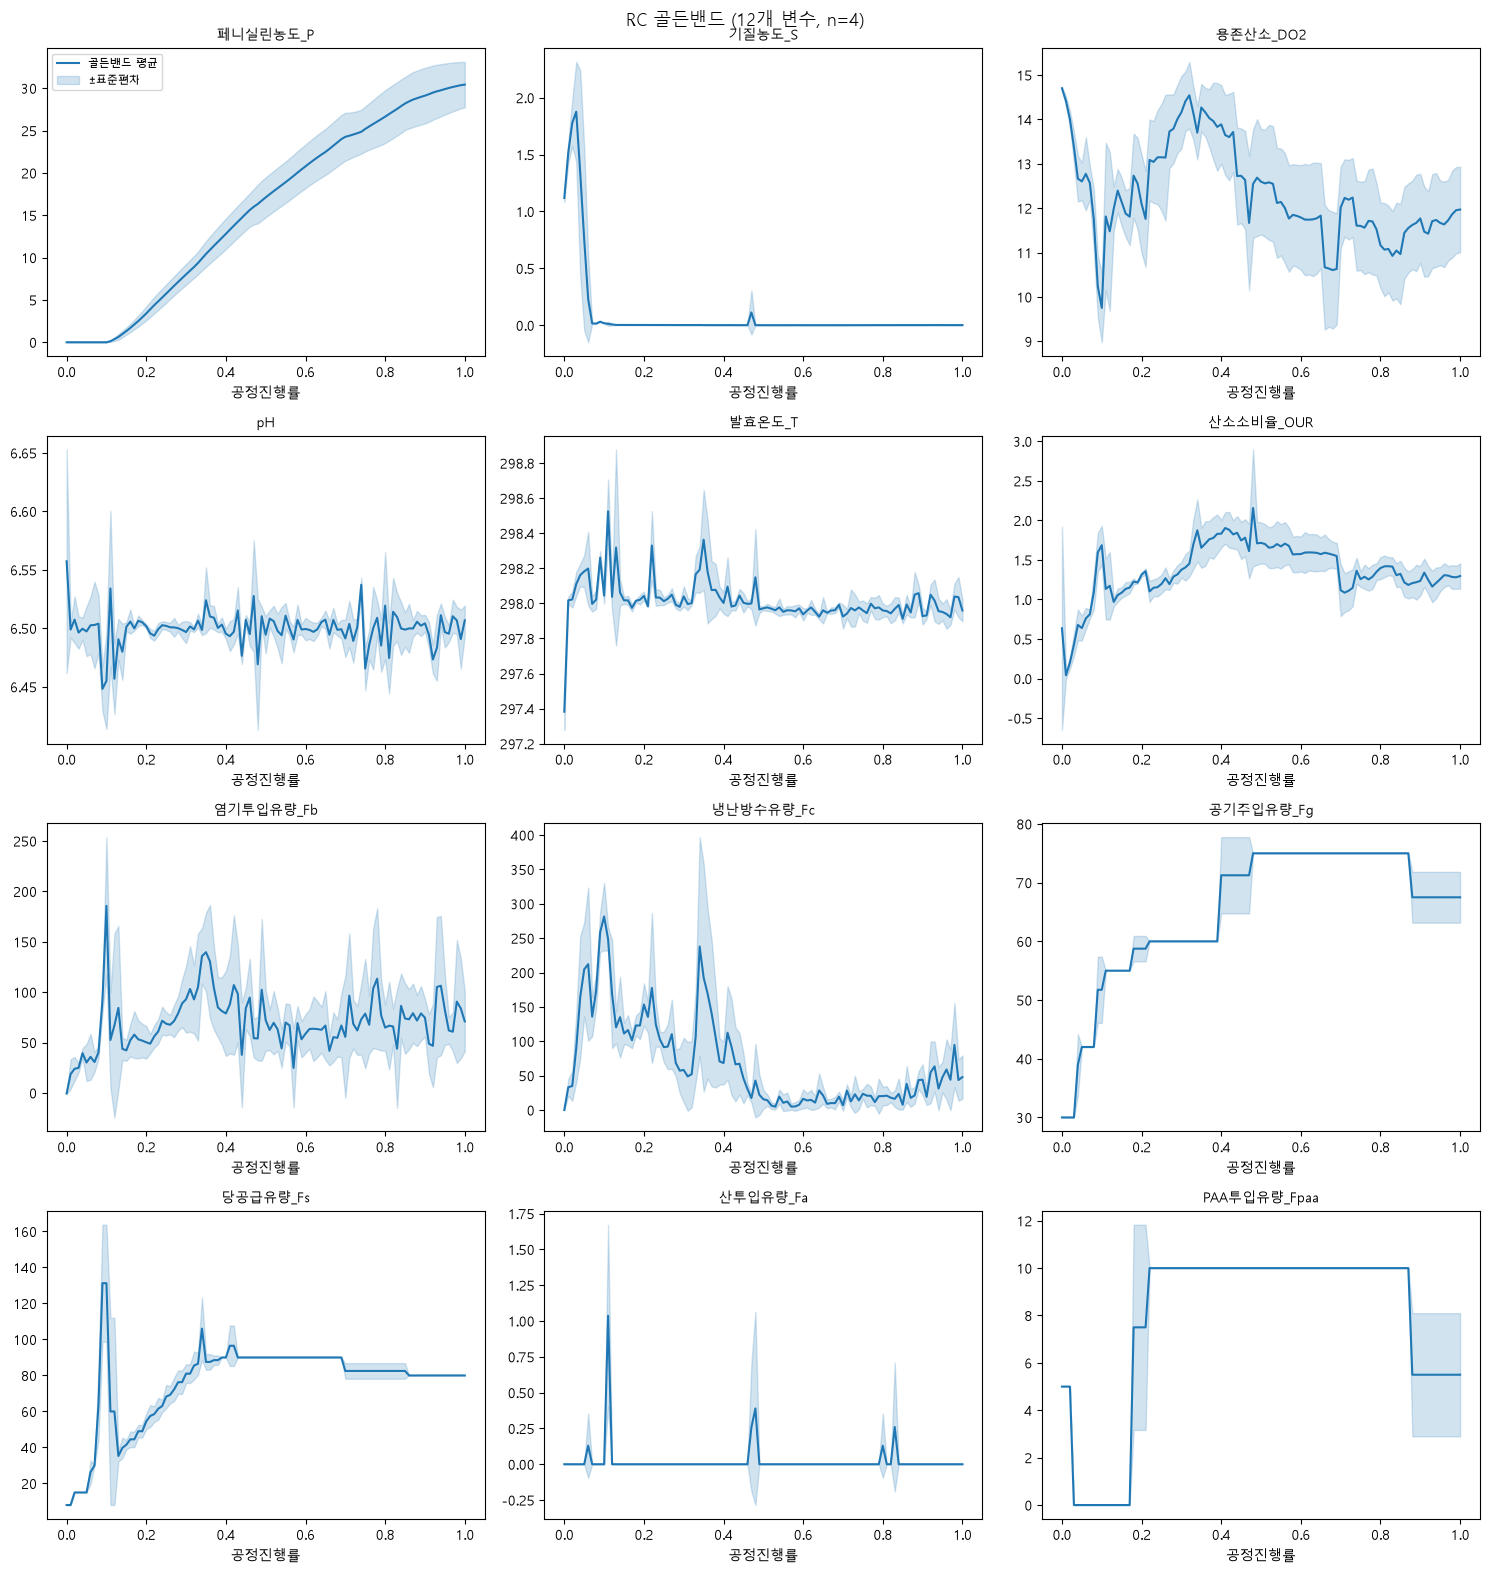

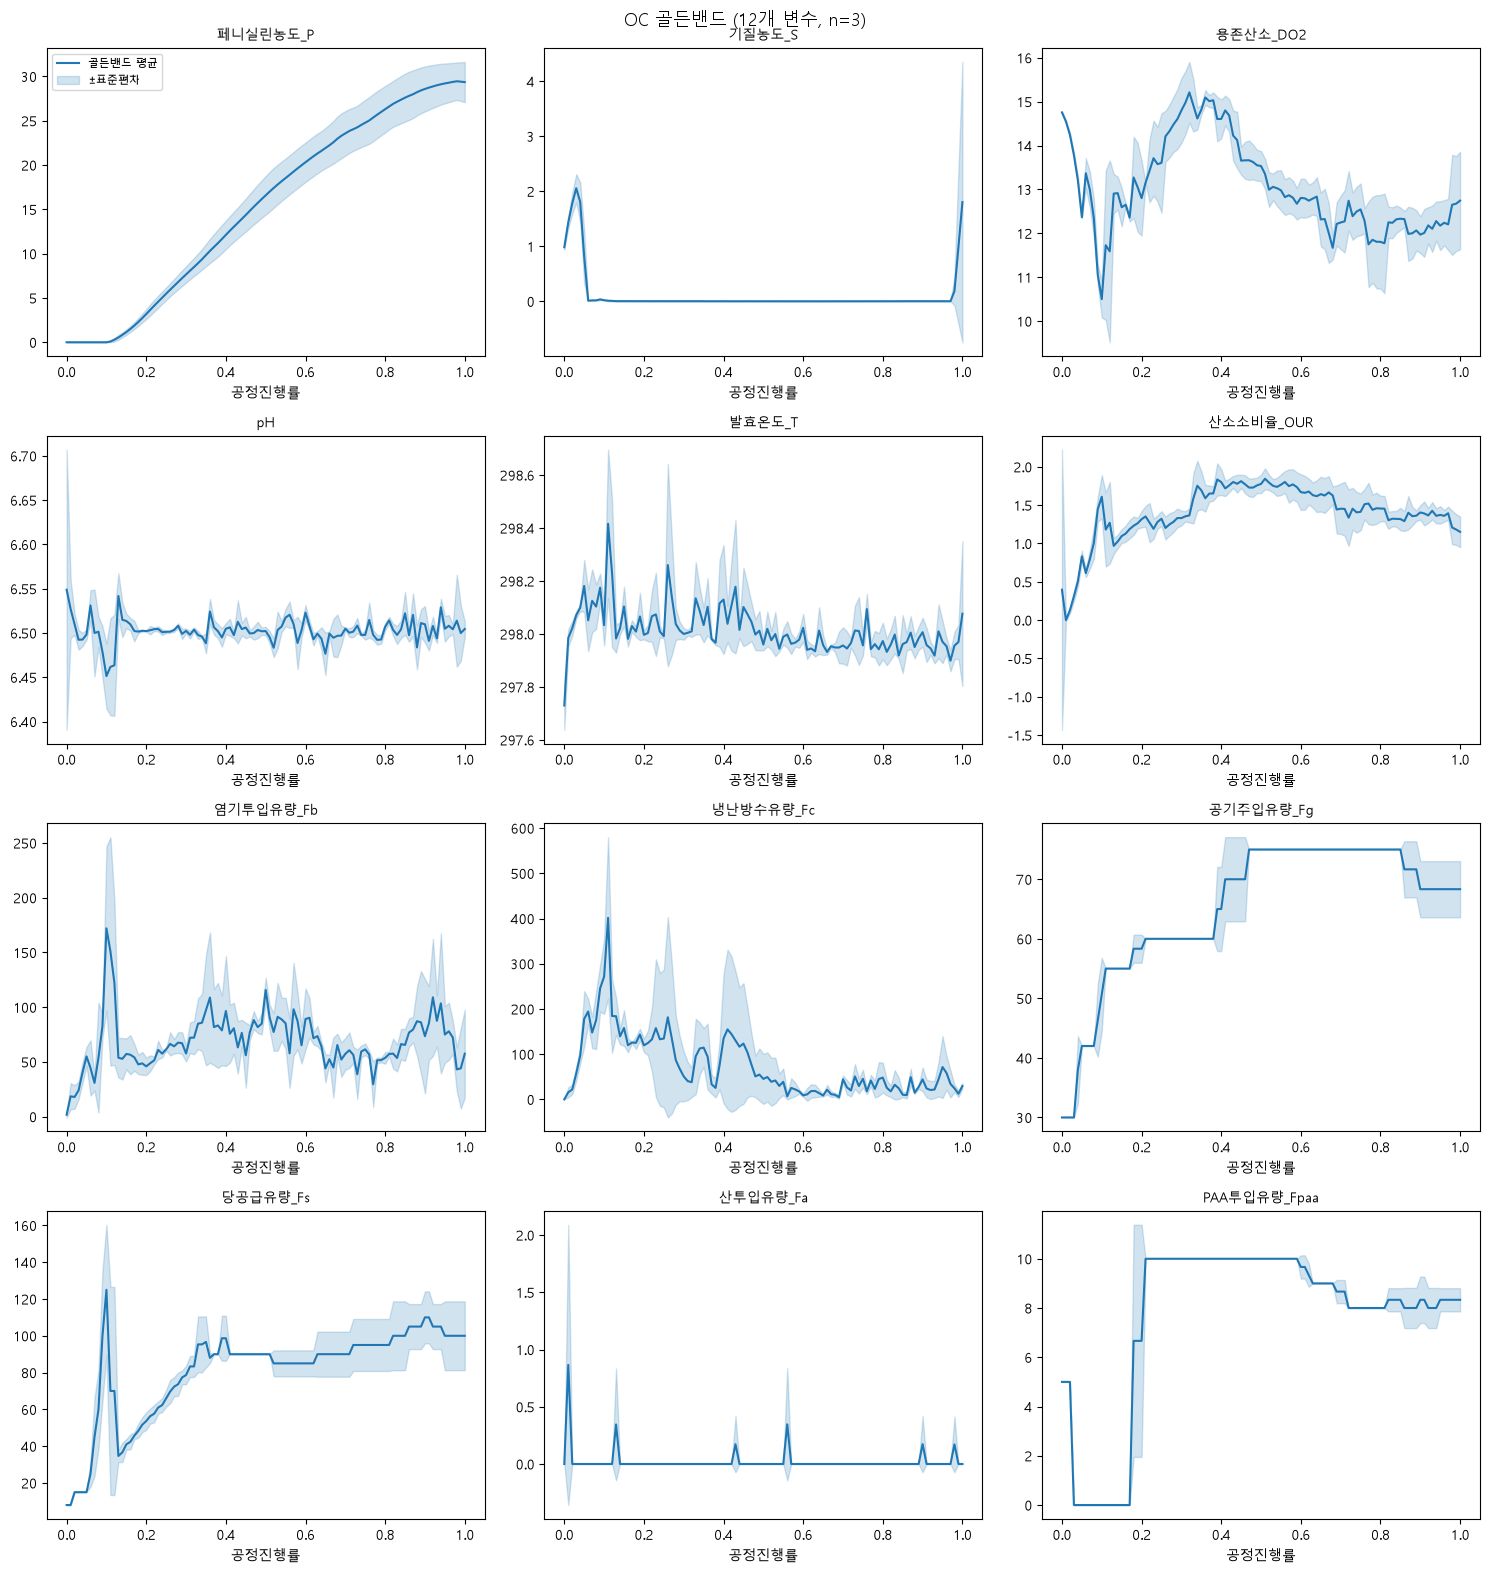

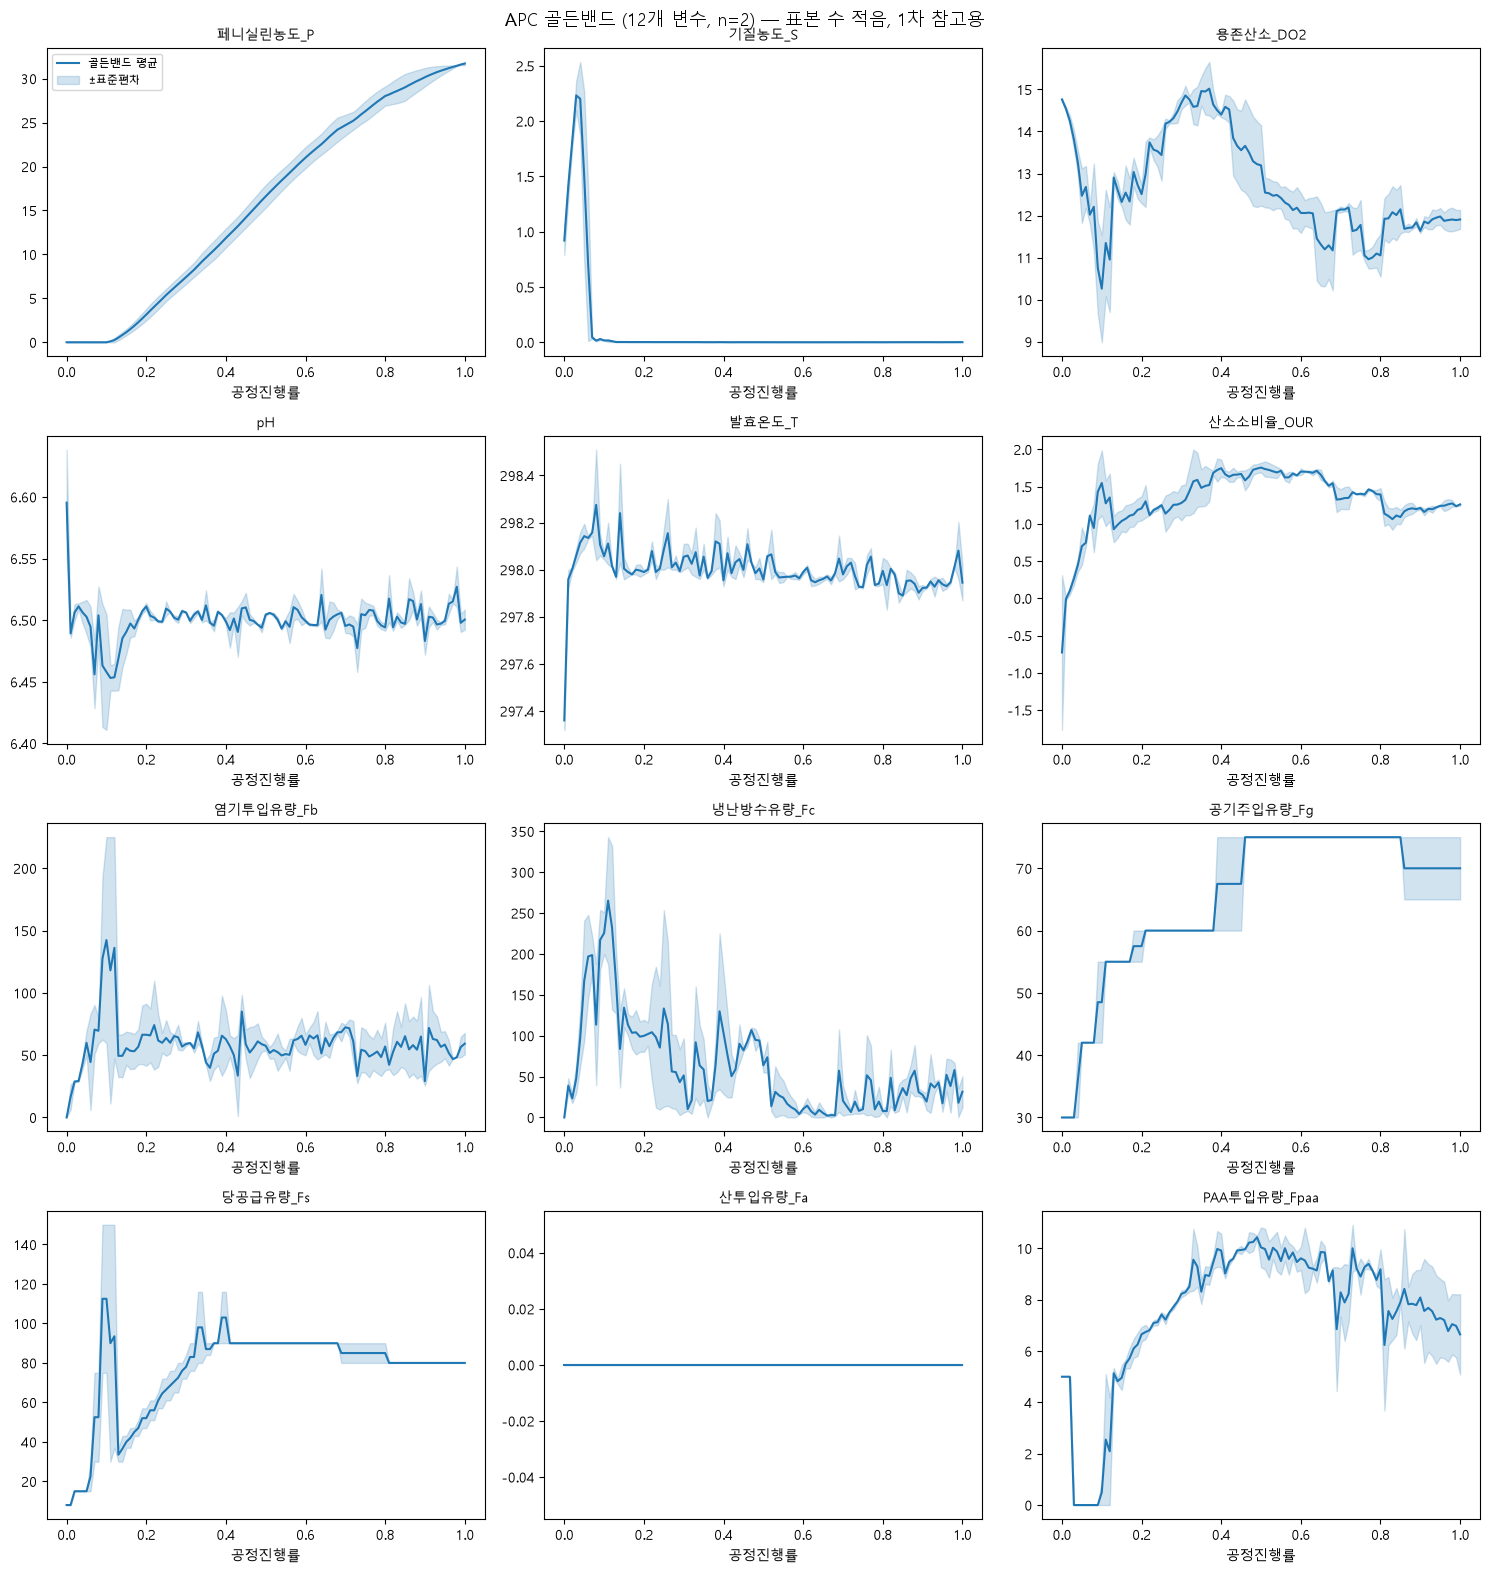

In [ ]:
def plot_golden_band(band, cols, strategy_name, n_batches=None):
    n = len(cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        mean = band[f'{col}_mean']
        std = band[f'{col}_std']
        x = band['공정진행률']
        ax.plot(x, mean, color='tab:blue', label='골든배치 평균')
        ax.fill_between(x, mean-std, mean+std, color='tab:blue', alpha=0.2, label='±표준편차')
        ax.set_title(col, fontsize=10)
        ax.set_xlabel('공정진행률')
        if i == 0:
            ax.legend(fontsize=8)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    title = f'{strategy_name} 골든배치 (12개 변수, n={n_batches})'
    if n_batches is not None and n_batches <= 2:
        title += ' — 표본 수 적음, 1차 참고용'
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

for strategy in golden_batches:
    plot_golden_band(bands[strategy], feature_cols, strategy, n_batches=len(golden_batches[strategy]))

# 골든배치에 52번 겹쳐서 비교

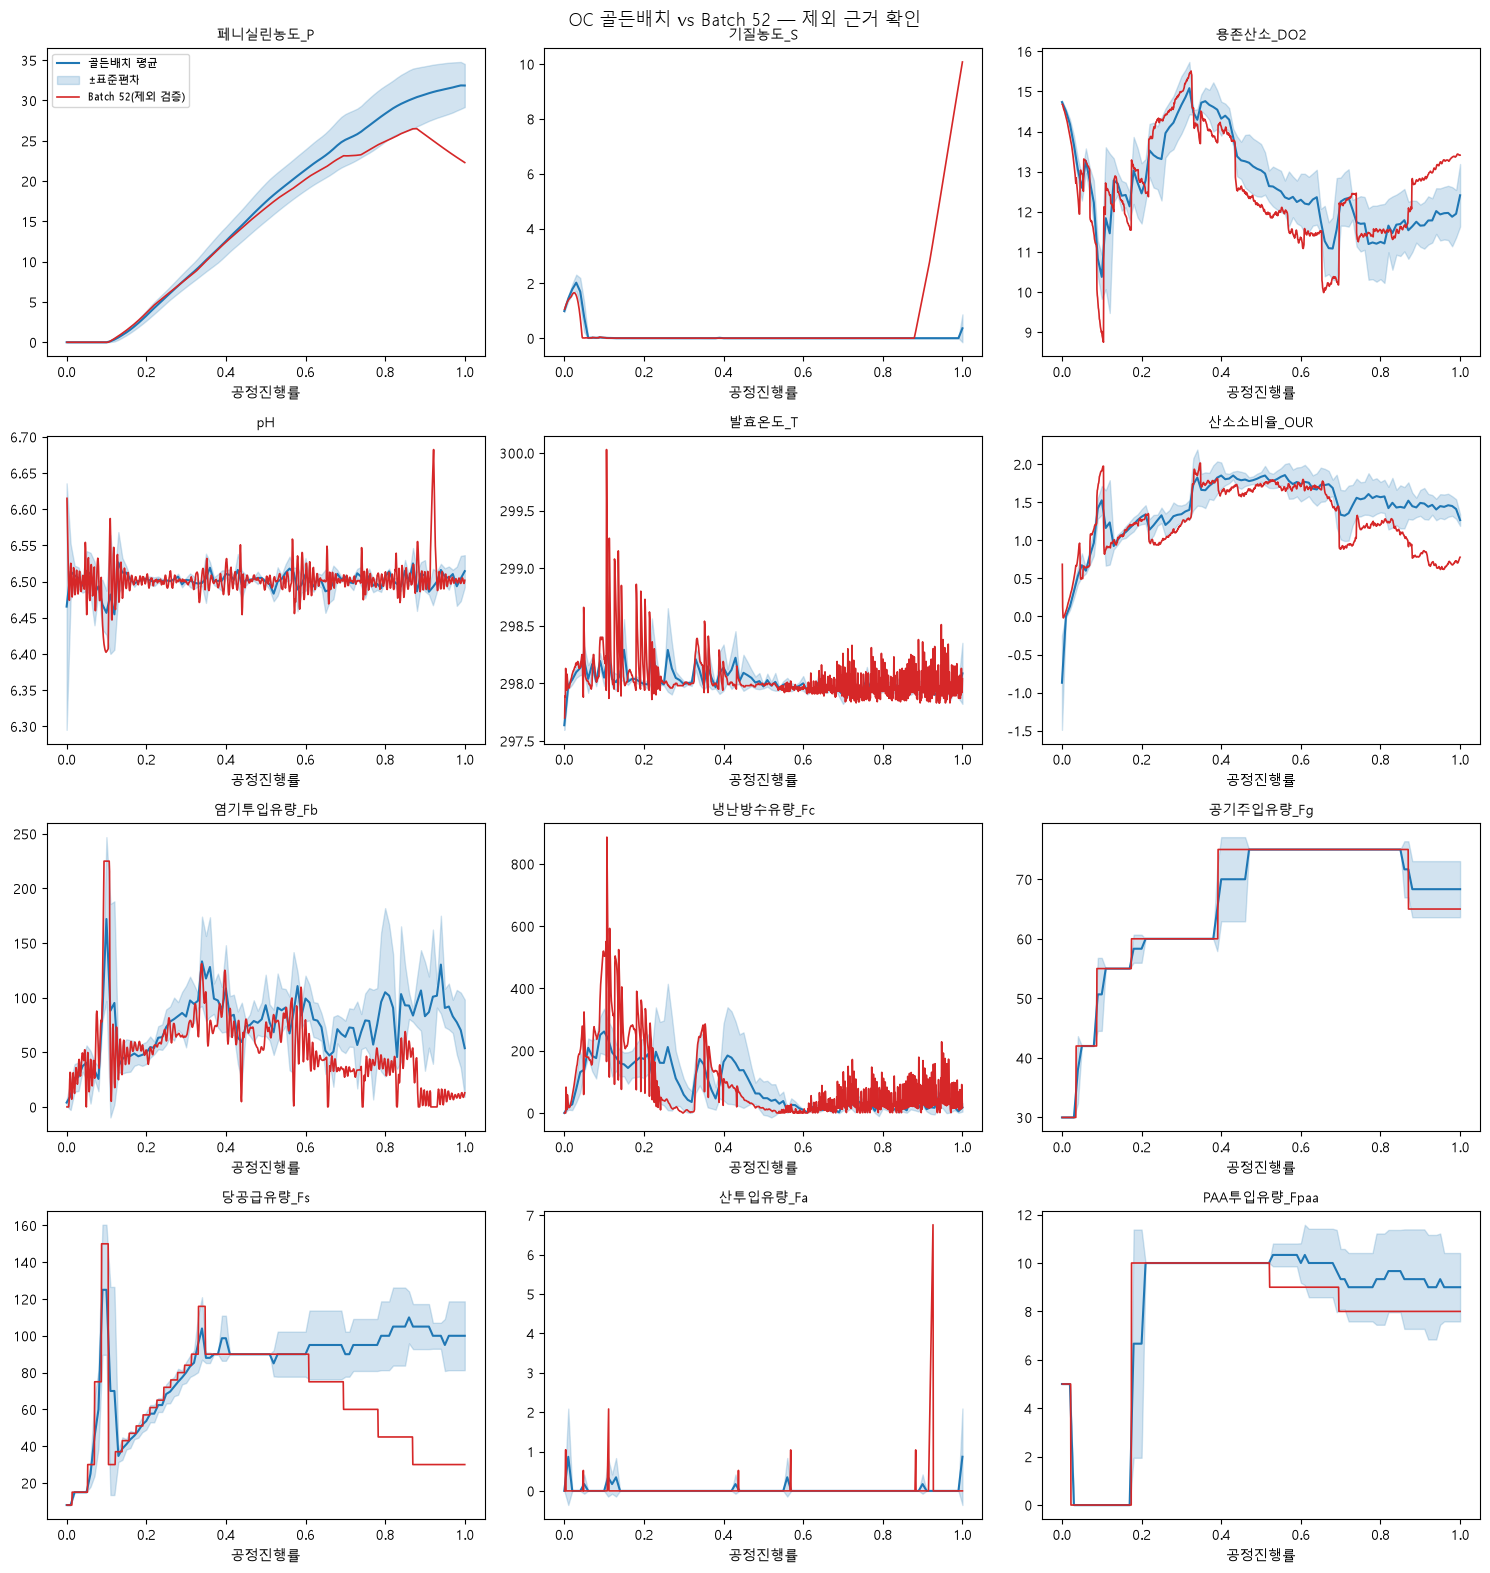

In [47]:
# 52번 제외 근거를 보여주는 비교 시각화
# OC 1차 기준 프로파일(35, 55, 57)과 Batch 52 비교

def plot_golden_band_with_check(band, cols, strategy_name, check_batch):
    n = len(cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        mean = band[f'{col}_mean']
        std = band[f'{col}_std']
        x = band['공정진행률']

        ax.plot(x, mean, color='tab:blue', label='골든배치 평균')
        ax.fill_between(x, mean-std, mean+std, color='tab:blue', alpha=0.2, label='±표준편차')

        # 검토 대상 배치(52번) 겹쳐 그리기
        sub = df[df[batch_col] == check_batch].sort_values(time_col)
        progress = sub[time_col] / sub[time_col].max()
        ax.plot(progress, sub[col], color='tab:red', linewidth=1.2, label=f'Batch {check_batch}(제외 검증)')

        ax.set_title(col, fontsize=10)
        ax.set_xlabel('공정진행률')
        if i == 0:
            ax.legend(fontsize=8)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle(f'{strategy_name} 골든배치 vs Batch {check_batch} — 제외 근거 확인', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_golden_band_with_check(bands['OC'], continuous_cols + step_cols, 'OC', check_batch=52)

# 8. (스트레치) 골든배치 표본 확대 검토

앞서 확정한 9개 골든배치는 표본 수(특히 OC 3개, APC 2개)가 적어 통계적으로
안정된 정상 범위라 보기 어렵다는 한계가 있었다. 이에 순위 6~10위(상위 20~40%)
구간의 배치들도 동일한 방식(하락률 검증)으로 추가 검토한다.

**주의: 이 섹션 결과로 9개 확정이 바뀌는 게 아니라, 표본을 늘릴 수 있는지
확인하는 별도의 검토 단계다.**

# 전략별 Train 배치 전체 순위 확인

In [25]:
# 전략별 Train 배치 총회수량 전체 순위 (20~40% 구간 파악용)
batch_summary_all = train_df.groupby([batch_col, strategy_col], as_index=False).agg(총회수량=(total_col,'first'))

for strategy in ['RC','OC','APC']:
    sub = batch_summary_all[batch_summary_all[strategy_col]==strategy].sort_values('총회수량', ascending=False).reset_index(drop=True)
    sub['순위'] = sub.index + 1
    print(f'=== {strategy} (Train {len(sub)}개) ===')
    print(sub[[batch_col,'총회수량','순위']].to_string(index=False))
    print()

=== RC (Train 24개) ===
 배치번호      총회수량  순위
    9 4083100.0   1
   12 3970100.0   2
   26 3886800.0   3
    8 3877400.0   4
   17 3851900.0   5
   25 3716900.0   6
   14 3585600.0   7
   16 3579300.0   8
   30 3538800.0   9
    7 3454600.0  10
   15 2852600.0  11
   22 2777700.0  12
   28 2709400.0  13
    3 2675300.0  14
   21 2568300.0  15
    6 2388700.0  16
    2 2326000.0  17
   20 2233600.0  18
   27 2176200.0  19
   18 2013500.0  20
   10 1982000.0  21
   24 1958400.0  22
    4 1886700.0  23
   29 1842400.0  24

=== OC (Train 23개) ===
 배치번호      총회수량  순위
   57 4059100.0   1
   60 3802300.0   2
   55 3784400.0   3
   52 3757800.0   4
   35 3537900.0   5
   33 3294100.0   6
   48 3265000.0   7
   50 3064900.0   8
   41 2922100.0   9
   51 2918500.0  10
   59 2910000.0  11
   53 2857800.0  12
   58 2757500.0  13
   56 2722600.0  14
   39 2681700.0  15
   37 2631900.0  16
   49 2596900.0  17
   47 2586400.0  18
   38 2391500.0  19
   42 2358500.0  20
   43 2212400.0  21
   36 1754100

순위 6~10위 하락률 검증 결과

| 전략 | 배치 | 정점농도 | 최종농도 | 하락률(%) | 판정 |
|---|---|---|---|---|---|
| RC | 25 | 23.16 | 12.23 | 47.2 | 불안정 |
| RC | **14** | 28.55 | 28.55 | **0.0** | **안정적** |
| RC | **16** | 32.12 | 32.12 | **0.0** | **안정적** |
| RC | 30 | 17.88 | 9.68 | 45.8 | 불안정 |
| RC | **7** | 29.42 | 29.42 | **0.0** | **안정적** |
| OC | 33 | 24.55 | 13.19 | 46.3 | 불안정 |
| OC | **48** | 35.09 | 34.76 | **0.9** | **안정적** |
| OC | 50 | 30.31 | 25.03 | 17.4 | 52번과 유사 — 제외 |
| OC | 41 | 29.22 | 26.75 | 8.5 | 경계선 — 팀 논의 필요 |
| OC | 51 | 16.25 | 9.01 | 44.6 | 불안정 |
| APC | **65** | 32.21 | 32.21 | **0.0** | **안정적** |
| APC | **69** | 27.35 | 27.27 | **0.3** | **안정적** |
| APC | **62** | 32.20 | 32.20 | **0.0** | **안정적** |
| APC | **82** | 30.01 | 30.01 | **0.0** | **안정적** |
| APC | **68** | 29.77 | 29.77 | **0.0** | **안정적** |

In [29]:
# 기존 상위 20%(순위1~5) 다음 구간(순위6~10)의 하락률 확인
next_tier = {}
for strategy in ['RC','OC','APC']:
    sub = batch_summary_all[batch_summary_all[strategy_col]==strategy].sort_values('총회수량', ascending=False).reset_index(drop=True)
    next_tier[strategy] = sub[batch_col].iloc[5:10].tolist()  # 순위 6~10위

print(f"{'전략':>5} {'배치':>6} | {'정점농도':>8} | {'최종농도':>8} | {'하락률(%)':>9}")
for strategy, batches in next_tier.items():
    for b in batches:
        sub = df[df[batch_col]==b].sort_values(time_col)
        peak = sub[p_col].max()
        final = sub[p_col].iloc[-1]
        drop_pct = (peak-final)/peak*100
        print(f"{strategy:>5} {b:>6} | {peak:>8.2f} | {final:>8.2f} | {drop_pct:>9.1f}")

   전략     배치 |     정점농도 |     최종농도 |    하락률(%)
   RC     25 |    23.16 |    12.23 |      47.2
   RC     14 |    28.55 |    28.55 |       0.0
   RC     16 |    32.12 |    32.12 |       0.0
   RC     30 |    17.88 |     9.68 |      45.8
   RC      7 |    29.42 |    29.42 |       0.0
   OC     33 |    24.55 |    13.19 |      46.3
   OC     48 |    35.09 |    34.76 |       0.9
   OC     50 |    30.31 |    25.03 |      17.4
   OC     41 |    29.22 |    26.75 |       8.5
   OC     51 |    16.25 |     9.01 |      44.6
  APC     65 |    32.21 |    32.21 |       0.0
  APC     69 |    27.35 |    27.27 |       0.3
  APC     62 |    32.20 |    32.20 |       0.0
  APC     82 |    30.01 |    30.01 |       0.0
  APC     68 |    29.77 |    29.77 |       0.0


- **APC는 순위 6~10위 전부(65·69·62·82·68)가 하락률 0%대로 완벽히 안정적이다.** 기존 2개(79·85)에 5개를 더하면 최대 **7개**까지 확대 가능하다.
- **RC는 14·16·7번이 안정적**이다. 기존 4개(8·12·17·26)에 더하면 **7개**까지 확대 가능하다.
- **OC는 48번만 뚜렷이 안정적**이다(하락률 0.9%). 41번(8.5%)은 9개 확정 당시 제외한 52번(15.9%)보다는 낮지만 완전한 안정권은 아니어서 포함 여부는 별도 논의가 필요하다. 기존 3개(35·55·57)에 48번을 더하면 **4개**, 41번까지 포함하면 **5개**.

## 8-3. 확대 후보 요약 (잠정, 그래프 재확인 전)

| 전략 | 기존 9개 | 확대 후보 | 확대 시 |
|---|---|---|---|
| RC | 8, 12, 17, 26 | + 7, 14, 16 | 7개 |
| OC | 35, 55, 57 | + 48 (41은 논의 필요) | 4~5개 |
| APC | 79, 85 | + 65, 69, 62, 82, 68 | 7개 |

**다음 단계:** 이 확대 후보들도 9개 확정 때와 동일하게 궤적 그래프로 육안 재확인 후, 최종 골든배치 개수를 조정한다.

# 절대 농도 수준까지 포함한 재검증

In [30]:
# 확대 후보의 최종농도를 기존 9개 골든배치 최종농도 분포와 비교
golden_final_conc = {}
for strategy, batches in golden_batches.items():
    concs = []
    for b in batches:
        sub = df[df[batch_col]==b].sort_values(time_col)
        concs.append(sub[p_col].iloc[-1])
    golden_final_conc[strategy] = concs
    print(f"{strategy} 기존 골든배치 최종농도: {[round(c,2) for c in concs]}, 평균 {sum(concs)/len(concs):.2f}")

print()
expanded_candidates = {
    'RC': [7, 14, 16],
    'OC': [48, 41],
    'APC': [65, 69, 62, 82, 68]
}

print(f"{'전략':>5} {'배치':>6} | {'최종농도':>8} | {'기존평균과 차이':>12}")
for strategy, batches in expanded_candidates.items():
    avg = sum(golden_final_conc[strategy]) / len(golden_final_conc[strategy])
    for b in batches:
        sub = df[df[batch_col]==b].sort_values(time_col)
        final = sub[p_col].iloc[-1]
        diff = final - avg
        flag = ' ⚠️ 기존 평균보다 낮음' if diff < -2 else ''
        print(f"{strategy:>5} {b:>6} | {final:>8.2f} | {diff:>+8.2f}{flag}")

RC 기존 골든배치 최종농도: [np.float64(34.51), np.float64(30.1), np.float64(26.99), np.float64(30.1)], 평균 30.43
OC 기존 골든배치 최종농도: [np.float64(28.3), np.float64(27.27), np.float64(32.52)], 평균 29.36
APC 기존 골든배치 최종농도: [np.float64(31.53), np.float64(31.9)], 평균 31.71

   전략     배치 |     최종농도 |     기존평균과 차이
   RC      7 |    29.42 |    -1.01
   RC     14 |    28.55 |    -1.88
   RC     16 |    32.12 |    +1.70
   OC     48 |    34.76 |    +5.39
   OC     41 |    26.75 |    -2.62 ⚠️ 기존 평균보다 낮음
  APC     65 |    32.21 |    +0.50
  APC     69 |    27.27 |    -4.45 ⚠️ 기존 평균보다 낮음
  APC     62 |    32.20 |    +0.48
  APC     82 |    30.01 |    -1.70
  APC     68 |    29.77 |    -1.95


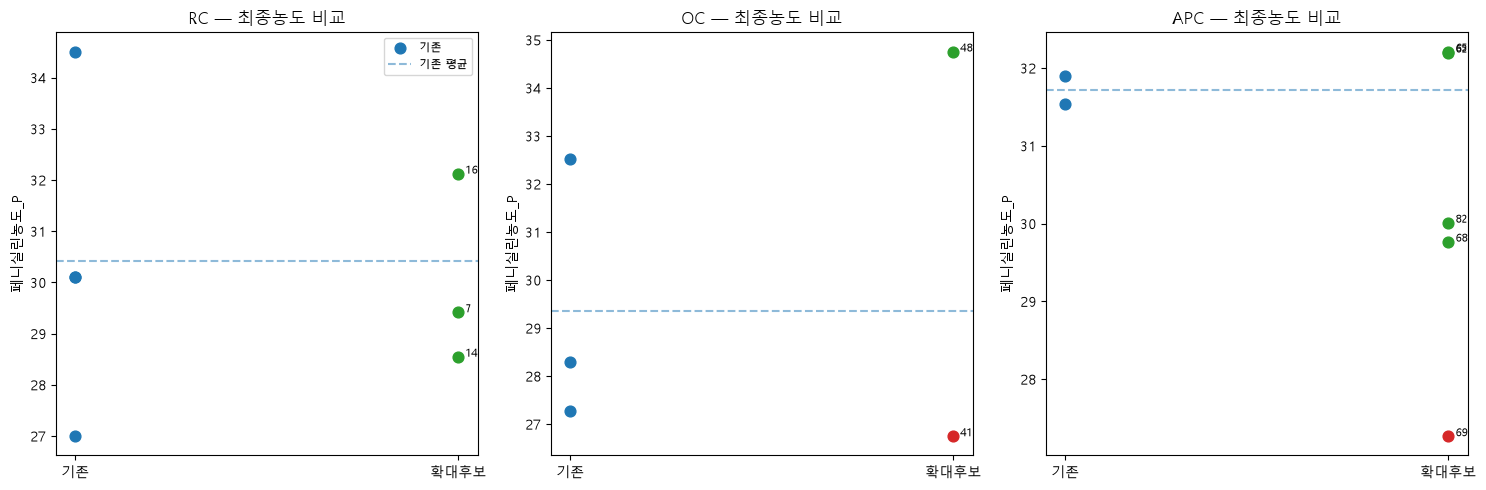

In [48]:
# 확대후보 vs 기존 골든배치 최종농도 분포 시각화 (박스플롯 또는 산점도)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

expanded_candidates = {
    'RC': [7, 14, 16],
    'OC': [48, 41],
    'APC': [65, 69, 62, 82, 68]
}

for ax, strategy in zip(axes, ['RC', 'OC', 'APC']):
    existing_concs = golden_final_conc[strategy]
    avg = sum(existing_concs) / len(existing_concs)

    # 기존 골든배치: 파란 점
    ax.scatter([0]*len(existing_concs), existing_concs, color='tab:blue', s=60, label='기존', zorder=3)
    ax.axhline(avg, color='tab:blue', linestyle='--', alpha=0.5, label='기존 평균')

    # 확대 후보: 배치별로 색 구분(기준 -2 이상 차이나면 빨강)
    for b in expanded_candidates[strategy]:
        sub = df[df[batch_col] == b].sort_values(time_col)
        final = sub[p_col].iloc[-1]
        diff = final - avg
        color = 'tab:red' if diff < -2 else 'tab:green'
        ax.scatter([1], [final], color=color, s=60, zorder=3)
        ax.annotate(str(b), (1, final), textcoords="offset points", xytext=(5,0), fontsize=8)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['기존', '확대후보'])
    ax.set_title(f'{strategy} — 최종농도 비교')
    ax.set_ylabel(p_col)

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# 확대 후보 궤적 시각화 (전략별로 신규/기존 구분)

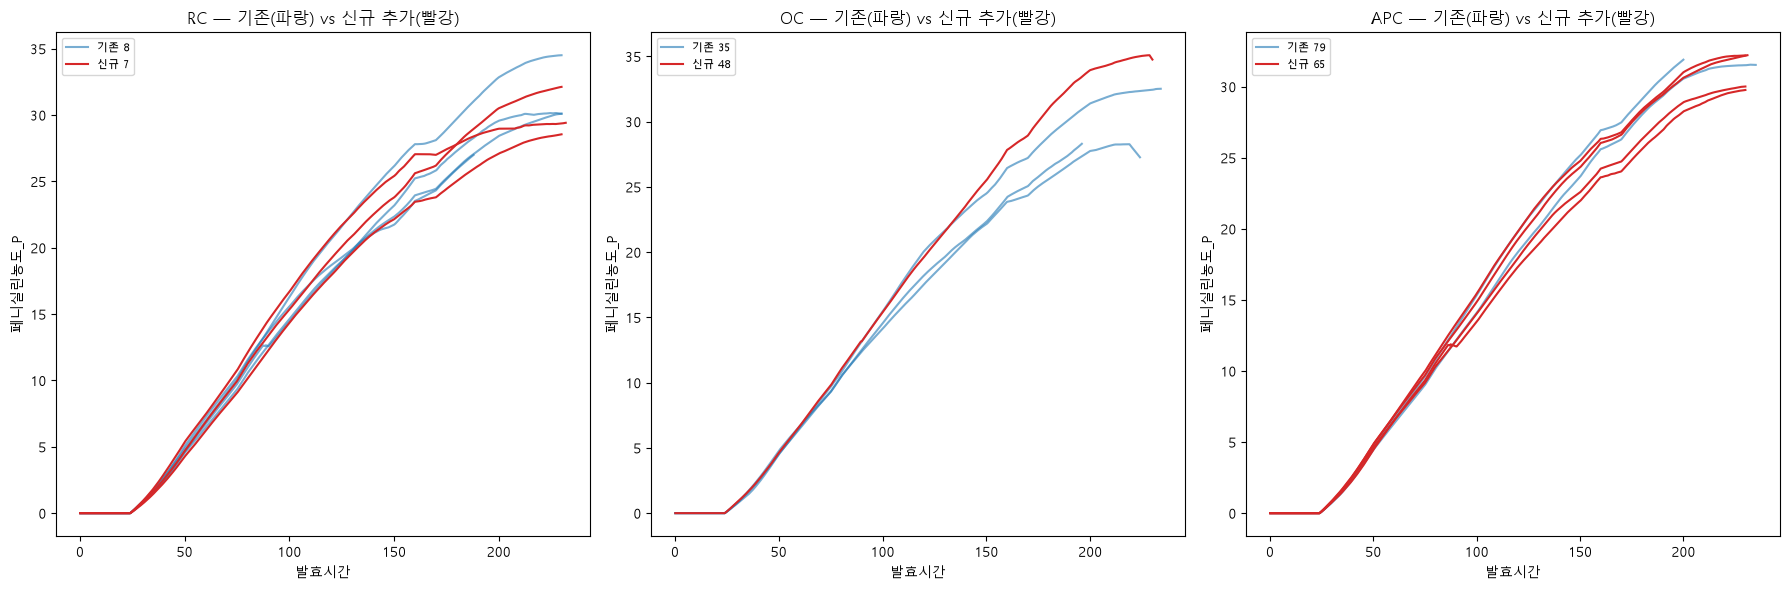

In [31]:
# 확대 후보를 기존 골든배치와 함께 궤적으로 재확인
final_expanded = {
    'RC': {'기존': [8, 12, 17, 26], '신규': [7, 14, 16]},
    'OC': {'기존': [35, 55, 57], '신규': [48]},
    'APC': {'기존': [79, 85], '신규': [65, 62, 82, 68]}
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, strategy in zip(axes, ['RC', 'OC', 'APC']):
    for b in final_expanded[strategy]['기존']:
        sub = df[df[batch_col] == b]
        ax.plot(sub[time_col], sub[p_col], color='tab:blue', alpha=0.6, label=f'기존 {b}' if b == final_expanded[strategy]['기존'][0] else None)
    for b in final_expanded[strategy]['신규']:
        sub = df[df[batch_col] == b]
        ax.plot(sub[time_col], sub[p_col], color='tab:red', linewidth=1.5, label=f'신규 {b}' if b == final_expanded[strategy]['신규'][0] else None)
    ax.set_title(f'{strategy} — 기존(파랑) vs 신규 추가(빨강)')
    ax.set_xlabel(time_col)
    ax.set_ylabel(p_col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

RC 재생성 완료: [8, 12, 17, 26, 7, 14, 16] (n=7)
OC 재생성 완료: [35, 55, 57, 48] (n=4)
APC 재생성 완료: [79, 85, 65, 62, 82, 68] (n=6)


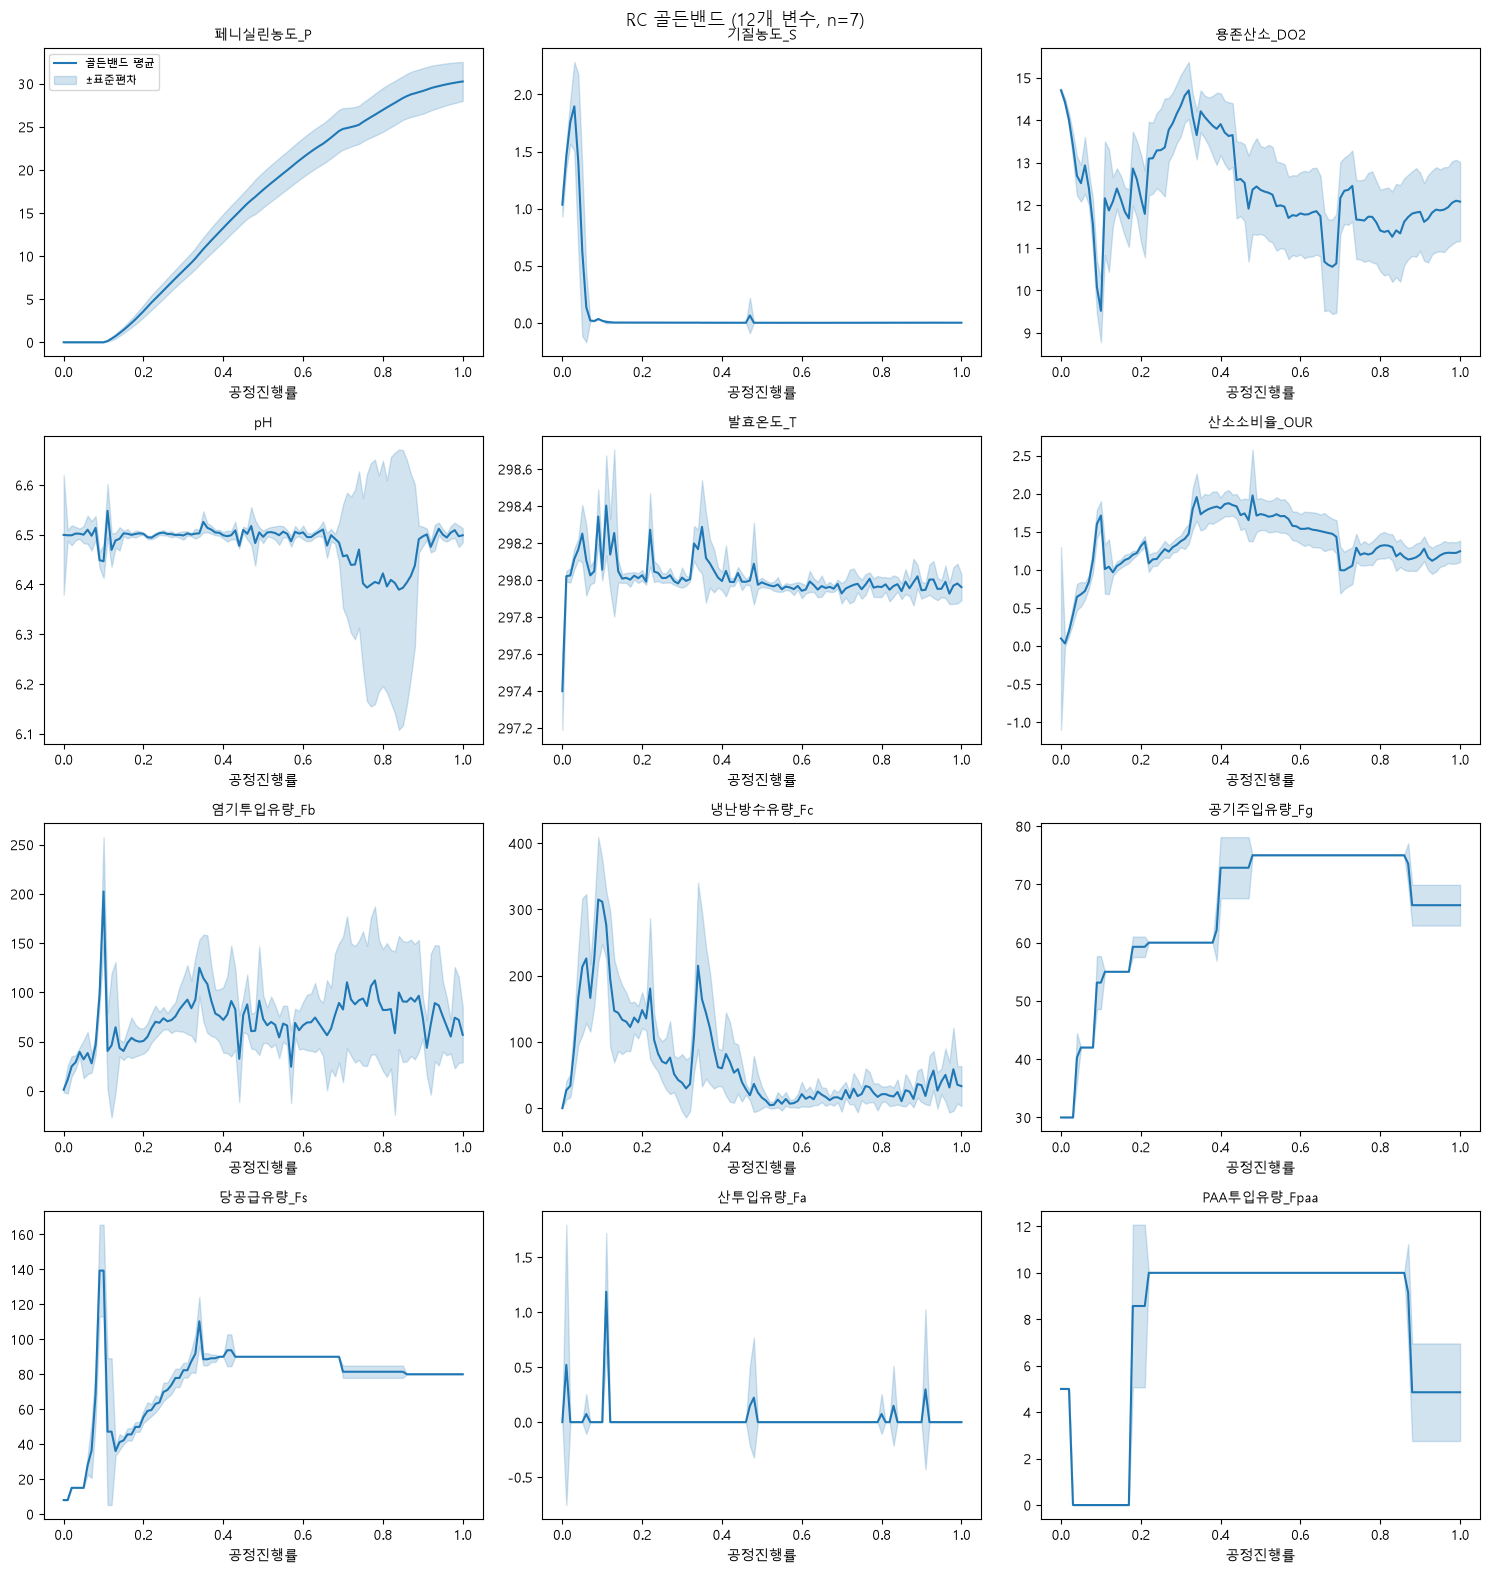

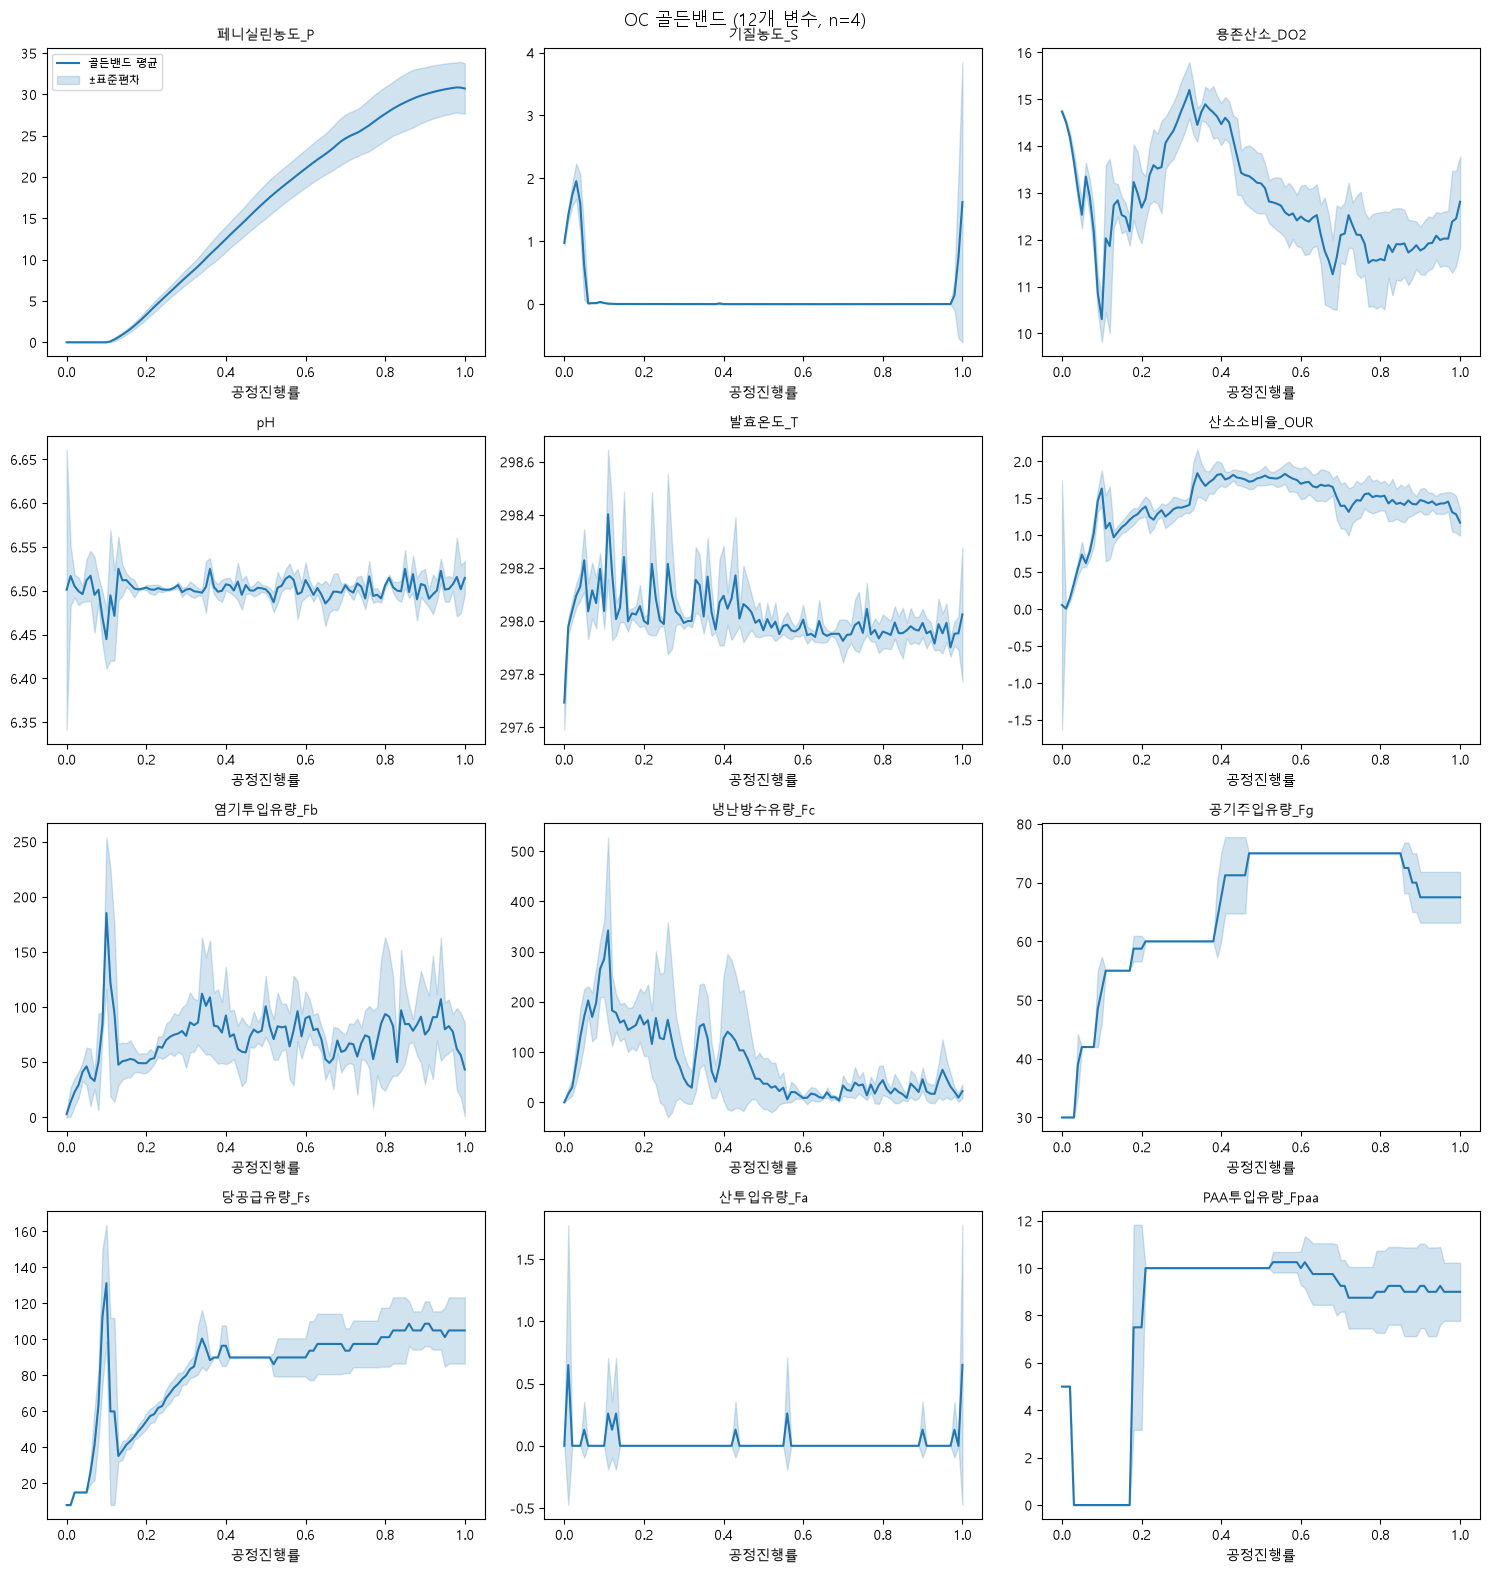

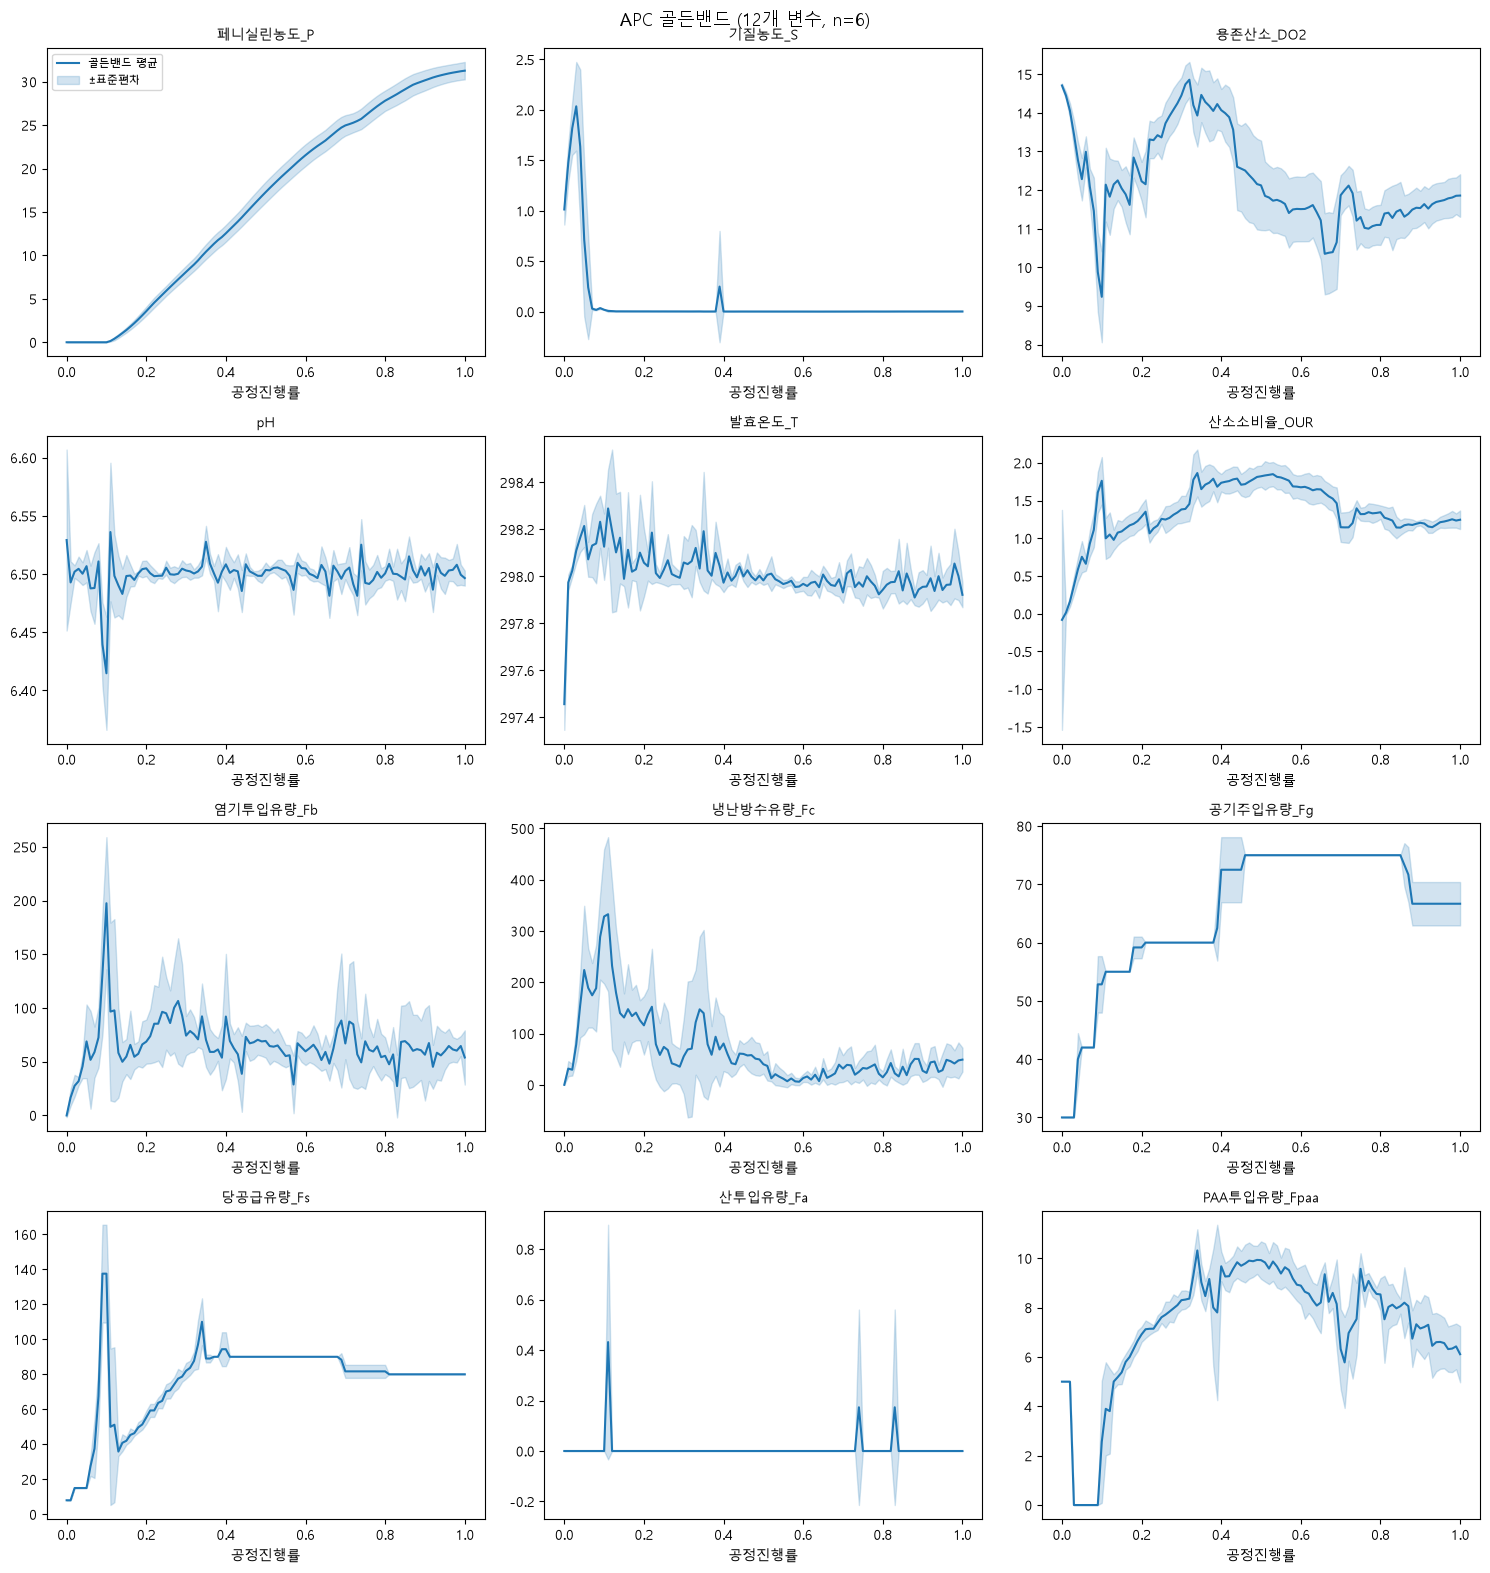

In [33]:
# 골든배치 최종 확정: 9개 → 17개로 확장 (궤적 그래프 + 하락률 수치 검증 완료)
golden_batches = {
    'RC': [8, 12, 17, 26, 7, 14, 16],
    'OC': [35, 55, 57, 48],
    'APC': [79, 85, 65, 62, 82, 68]
}

# 확장된 배치 명단으로 골든배치 기준 프로파일 재생성 (기존 build_golden_band 함수 그대로 재사용)
bands = {}
for strategy, batches in golden_batches.items():
    bands[strategy] = build_golden_band(df, batches, continuous_cols, step_cols, time_col)
    print(f"{strategy} 재생성 완료: {batches} (n={len(batches)})")

for strategy in golden_batches:
    plot_golden_band(bands[strategy], feature_cols, strategy, n_batches=len(golden_batches[strategy]))

# 배치별 이상치 스크리닝 (거리 계산)

In [34]:
# 골든배치 내에서 특정 변수가 유독 다른 패턴을 보이는 배치가 있는지 스크리닝
common_points = np.linspace(0, 1, 101)

def get_batch_curve(b, col):
    sub = df[df[batch_col] == b].sort_values(time_col)
    progress = sub[time_col] / sub[time_col].max()
    interp = PchipInterpolator(progress, sub[col])
    return interp(common_points)

def screen_outlier_batches(batches, col):
    curves = {b: get_batch_curve(b, col) for b in batches}
    mean_curve = np.mean(list(curves.values()), axis=0)
    dist = {b: np.sqrt(np.mean((curves[b] - mean_curve) ** 2)) for b in batches}
    return sorted(dist.items(), key=lambda x: -x[1])

for strategy, batches in golden_batches.items():
    print(f"\n=== {strategy} ===")
    for col in ['pH', s_col, '산투입유량_Fa']:
        print(f"  {col}: {screen_outlier_batches(batches, col)}")


=== RC ===
  pH: [(7, np.float64(0.22503922560888384)), (17, np.float64(0.04784985145363794)), (26, np.float64(0.04449160714166337)), (14, np.float64(0.04376243707965859)), (16, np.float64(0.04234693684097275)), (12, np.float64(0.04026984871246058)), (8, np.float64(0.03832725060900493))]
  기질농도_S: [(17, np.float64(0.17893494767942952)), (12, np.float64(0.15889554259472674)), (14, np.float64(0.1164257690573062)), (26, np.float64(0.10492790777437963)), (7, np.float64(0.0892199257590282)), (8, np.float64(0.0878294499668751)), (16, np.float64(0.06671139933369838))]
  산투입유량_Fa: [(17, np.float64(0.2367864915253573)), (14, np.float64(0.16617114542163003)), (26, np.float64(0.15804799661332772)), (7, np.float64(0.09236694804243327)), (16, np.float64(0.06726695973378877)), (8, np.float64(0.06457171205400623)), (12, np.float64(0.05114009077318464))]

=== OC ===
  pH: [(35, np.float64(0.027588927176674407)), (57, np.float64(0.025750943122590606)), (48, np.float64(0.023138126680986765)), (55, np.f

# 의심 배치 개별 오버레이

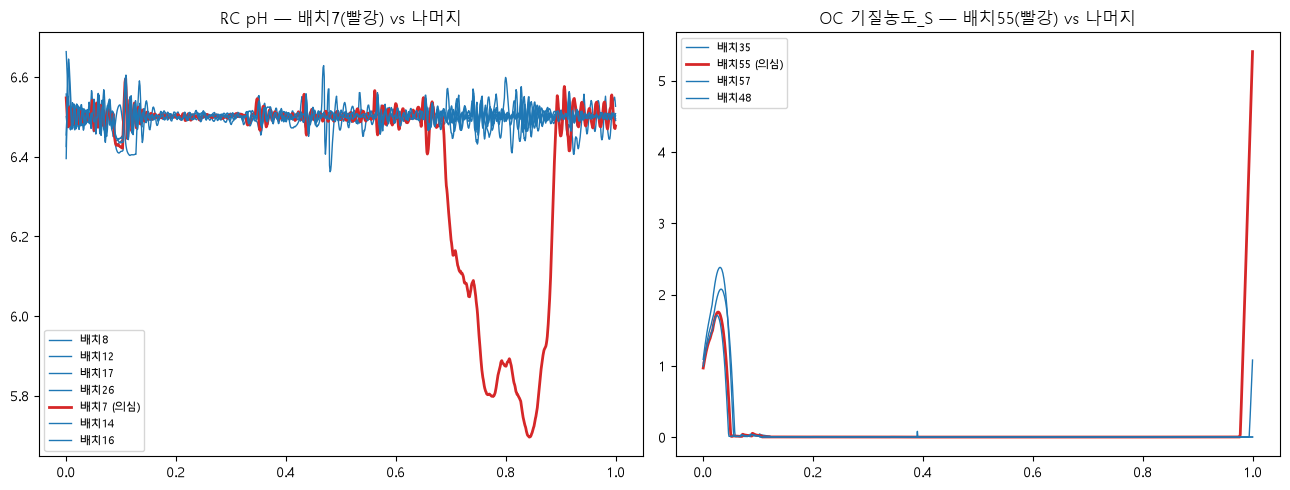

In [35]:
# RC 배치7 pH, OC 배치55 기질농도_S — 결과 보고 배치번호는 바꿔서 확인

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

suspect_col1, suspect_batch1, group1 = 'pH', 7, golden_batches['RC']
ax = axes[0]
for b in group1:
    color = 'tab:red' if b == suspect_batch1 else 'tab:blue'
    lw = 2 if b == suspect_batch1 else 1
    sub = df[df[batch_col] == b].sort_values(time_col)
    ax.plot(sub[time_col]/sub[time_col].max(), sub[suspect_col1], color=color, lw=lw,
             label=f'배치{b}' + (' (의심)' if b == suspect_batch1 else ''))
ax.set_title(f'RC {suspect_col1} — 배치{suspect_batch1}(빨강) vs 나머지')
ax.legend(fontsize=8)

suspect_col2, suspect_batch2, group2 = s_col, 55, golden_batches['OC']
ax = axes[1]
for b in group2:
    color = 'tab:red' if b == suspect_batch2 else 'tab:blue'
    lw = 2 if b == suspect_batch2 else 1
    sub = df[df[batch_col] == b].sort_values(time_col)
    ax.plot(sub[time_col]/sub[time_col].max(), sub[suspect_col2], color=color, lw=lw,
             label=f'배치{b}' + (' (의심)' if b == suspect_batch2 else ''))
ax.set_title(f'OC {suspect_col2} — 배치{suspect_batch2}(빨강) vs 나머지')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 최종 골든배치 확정 — 배치7·55 제외

In [43]:
# 확대후보 17개 중, 개별 오버레이로 확인한 이상치(RC 배치7 pH, OC 배치55 기질농도_S) 제외
# → 최종 15개 확정
golden_batches = {
    'RC':  [8, 12, 17, 26, 14, 16],
    'OC':  [35, 57, 48],
    'APC': [79, 85, 65, 62, 82, 68]
}

# 골든배치 기준 프로파일 재생성 (기존 build_golden_band 함수 그대로 재사용, 평균±SD 방식)
bands = {}
for strategy, batches in golden_batches.items():
    bands[strategy] = build_golden_band(df, batches, continuous_cols, step_cols, time_col)
    print(f"{strategy} 재생성 완료: {batches} (n={len(batches)})")

RC 재생성 완료: [8, 12, 17, 26, 14, 16] (n=6)
OC 재생성 완료: [35, 57, 48] (n=3)
APC 재생성 완료: [79, 85, 65, 62, 82, 68] (n=6)


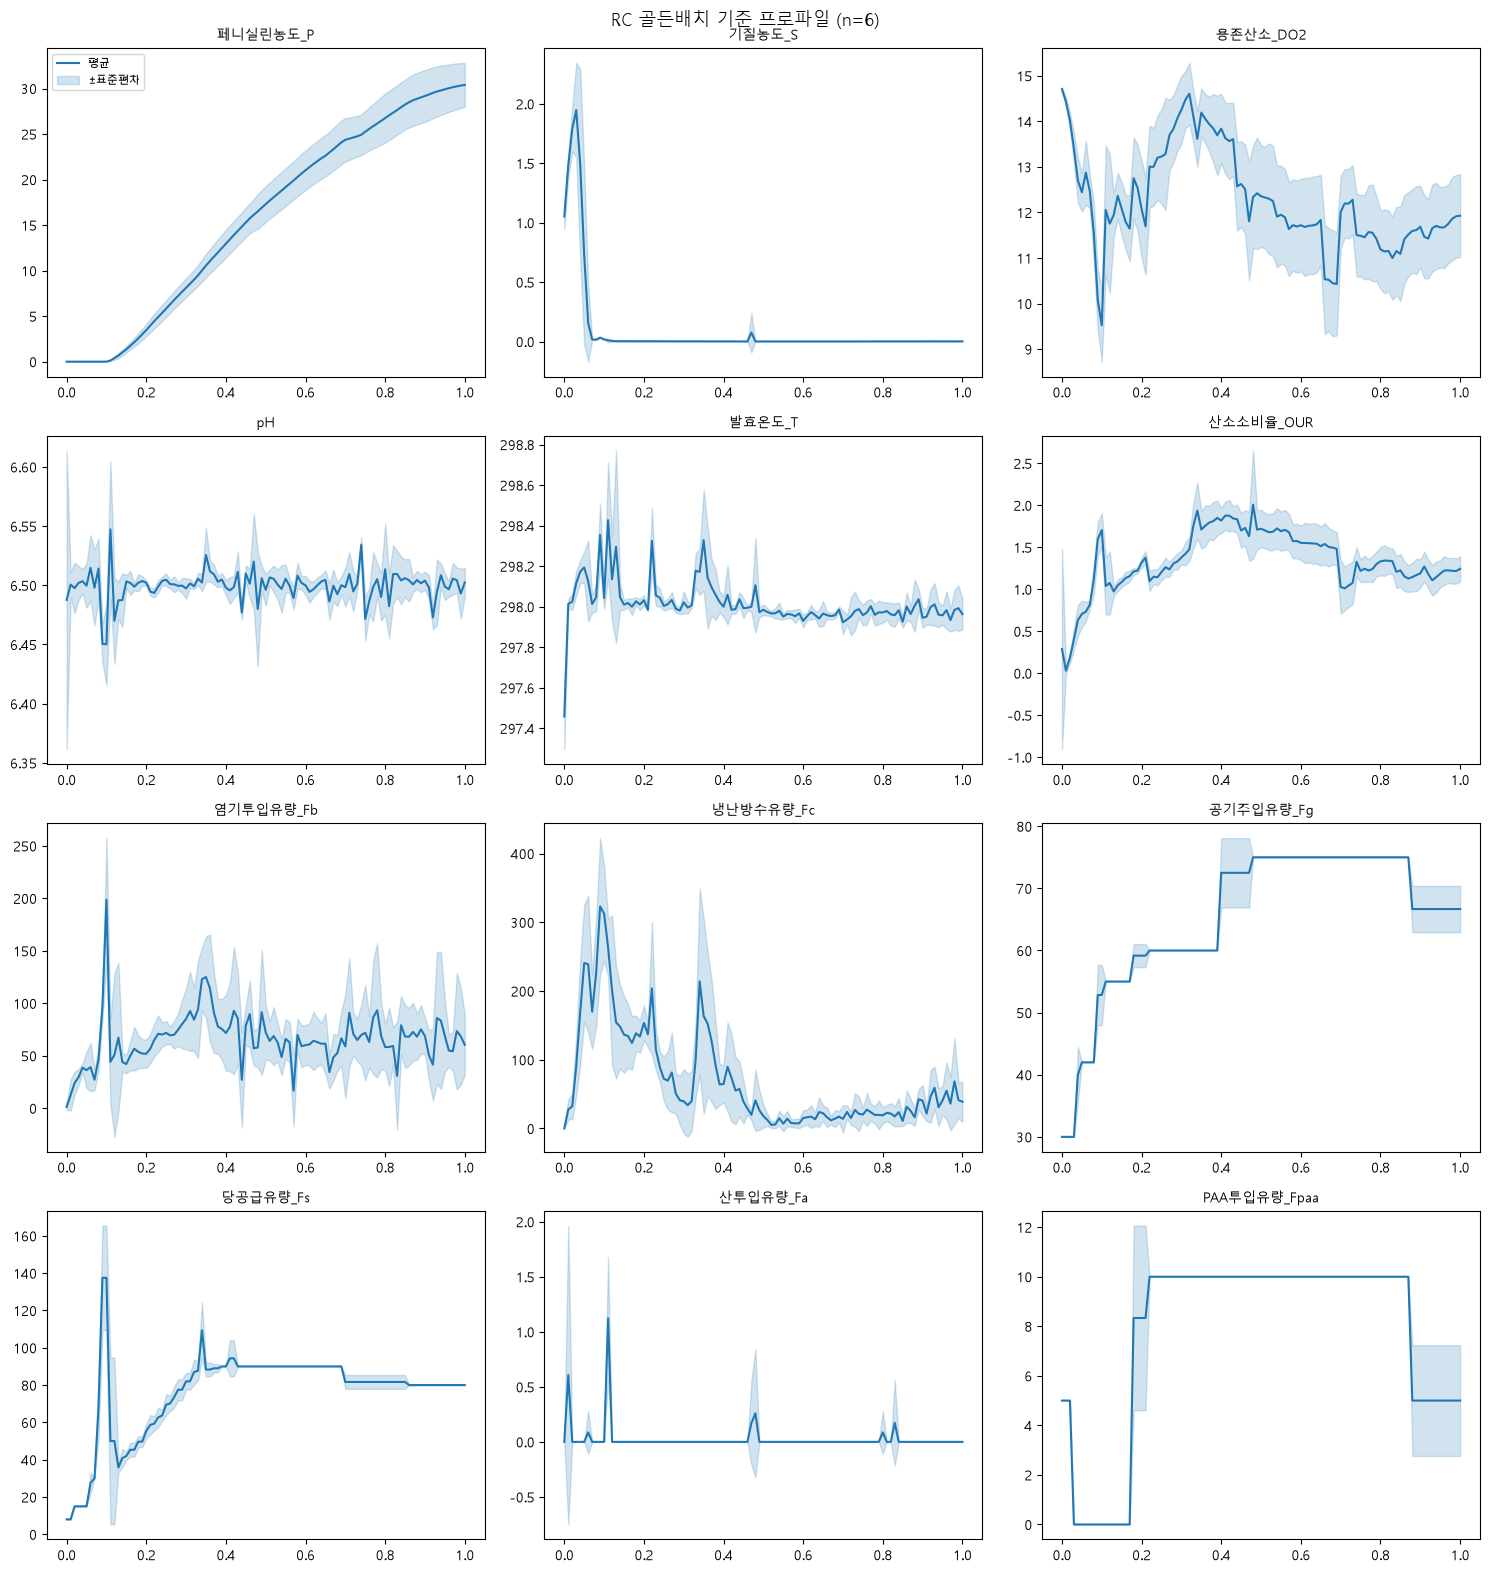

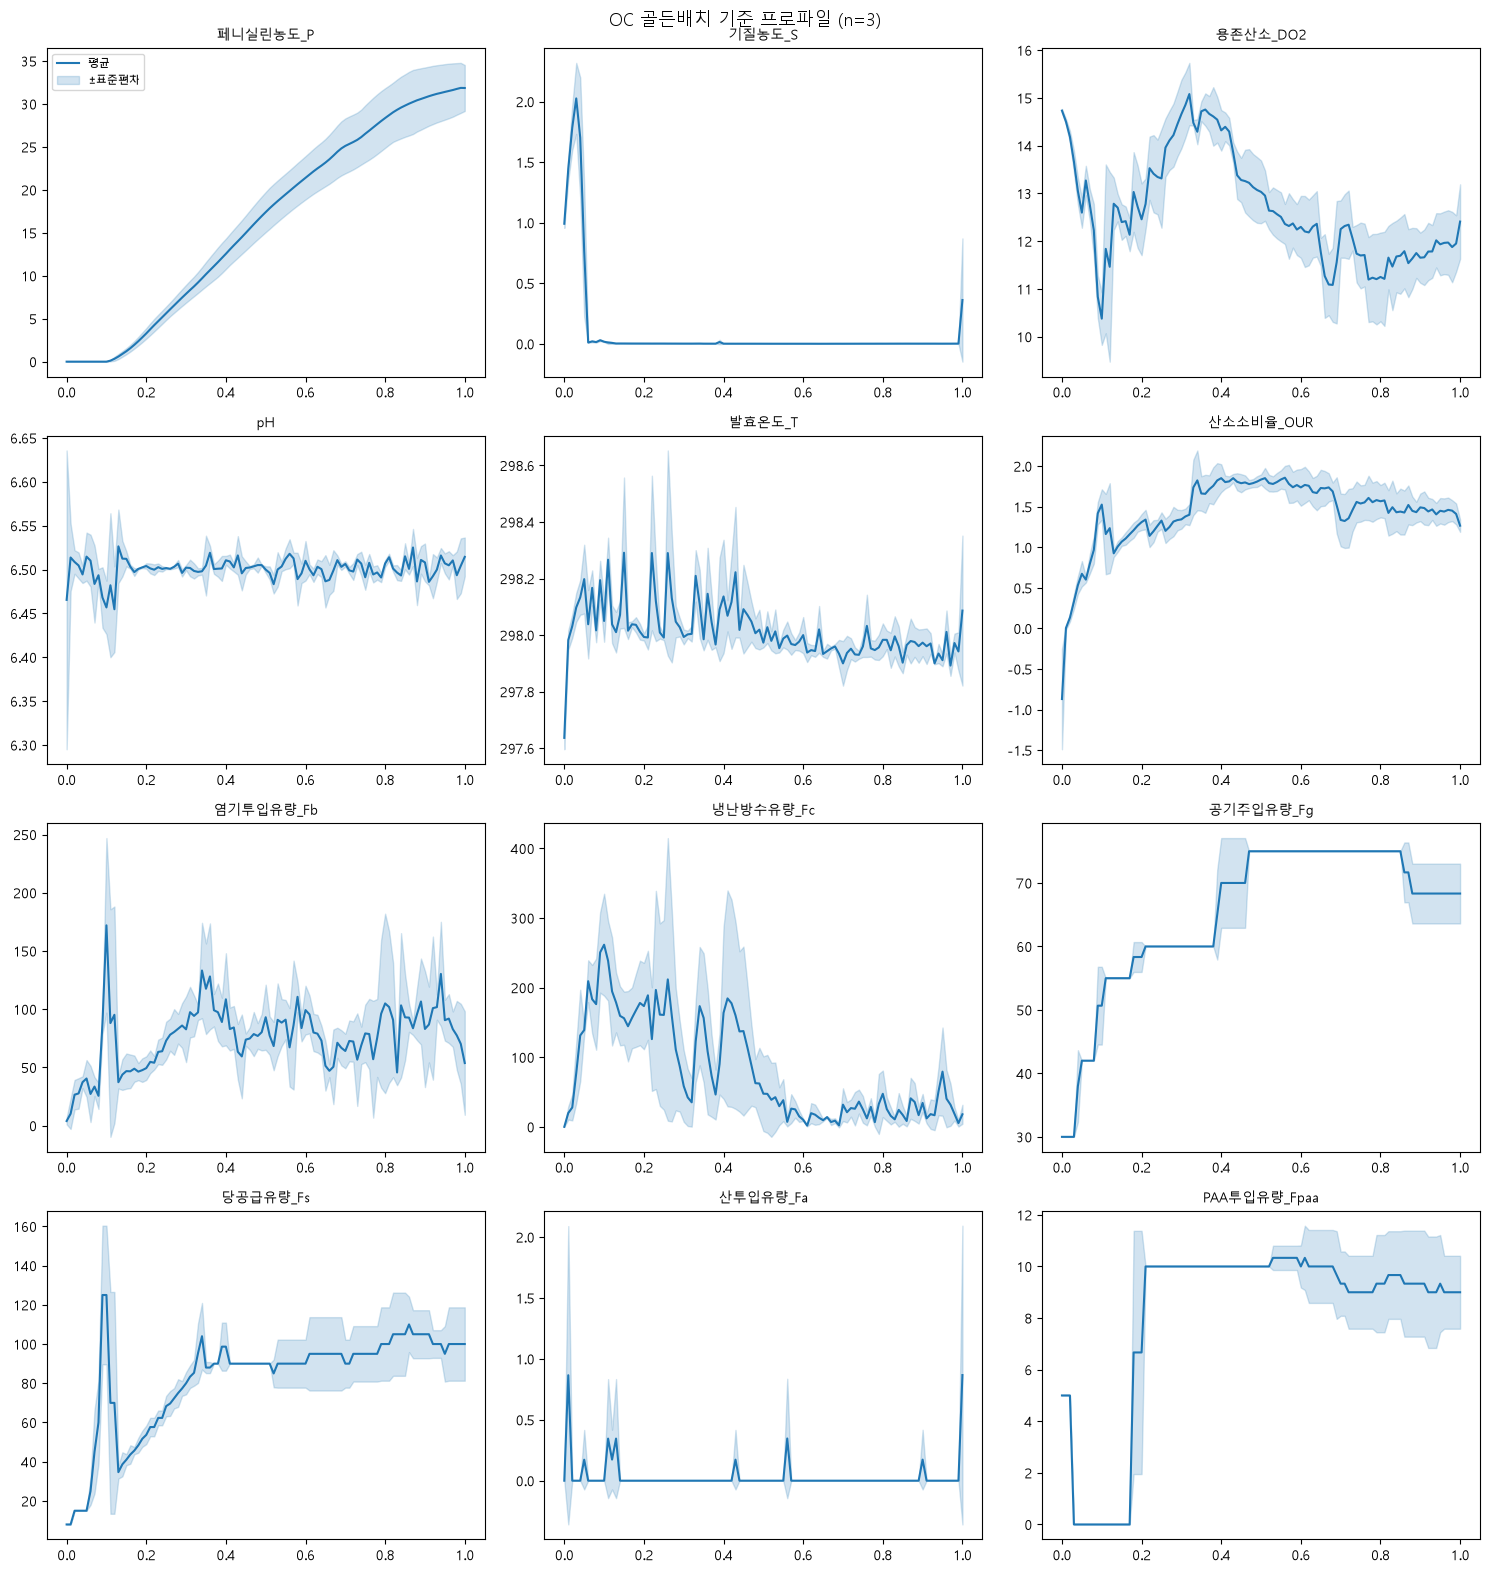

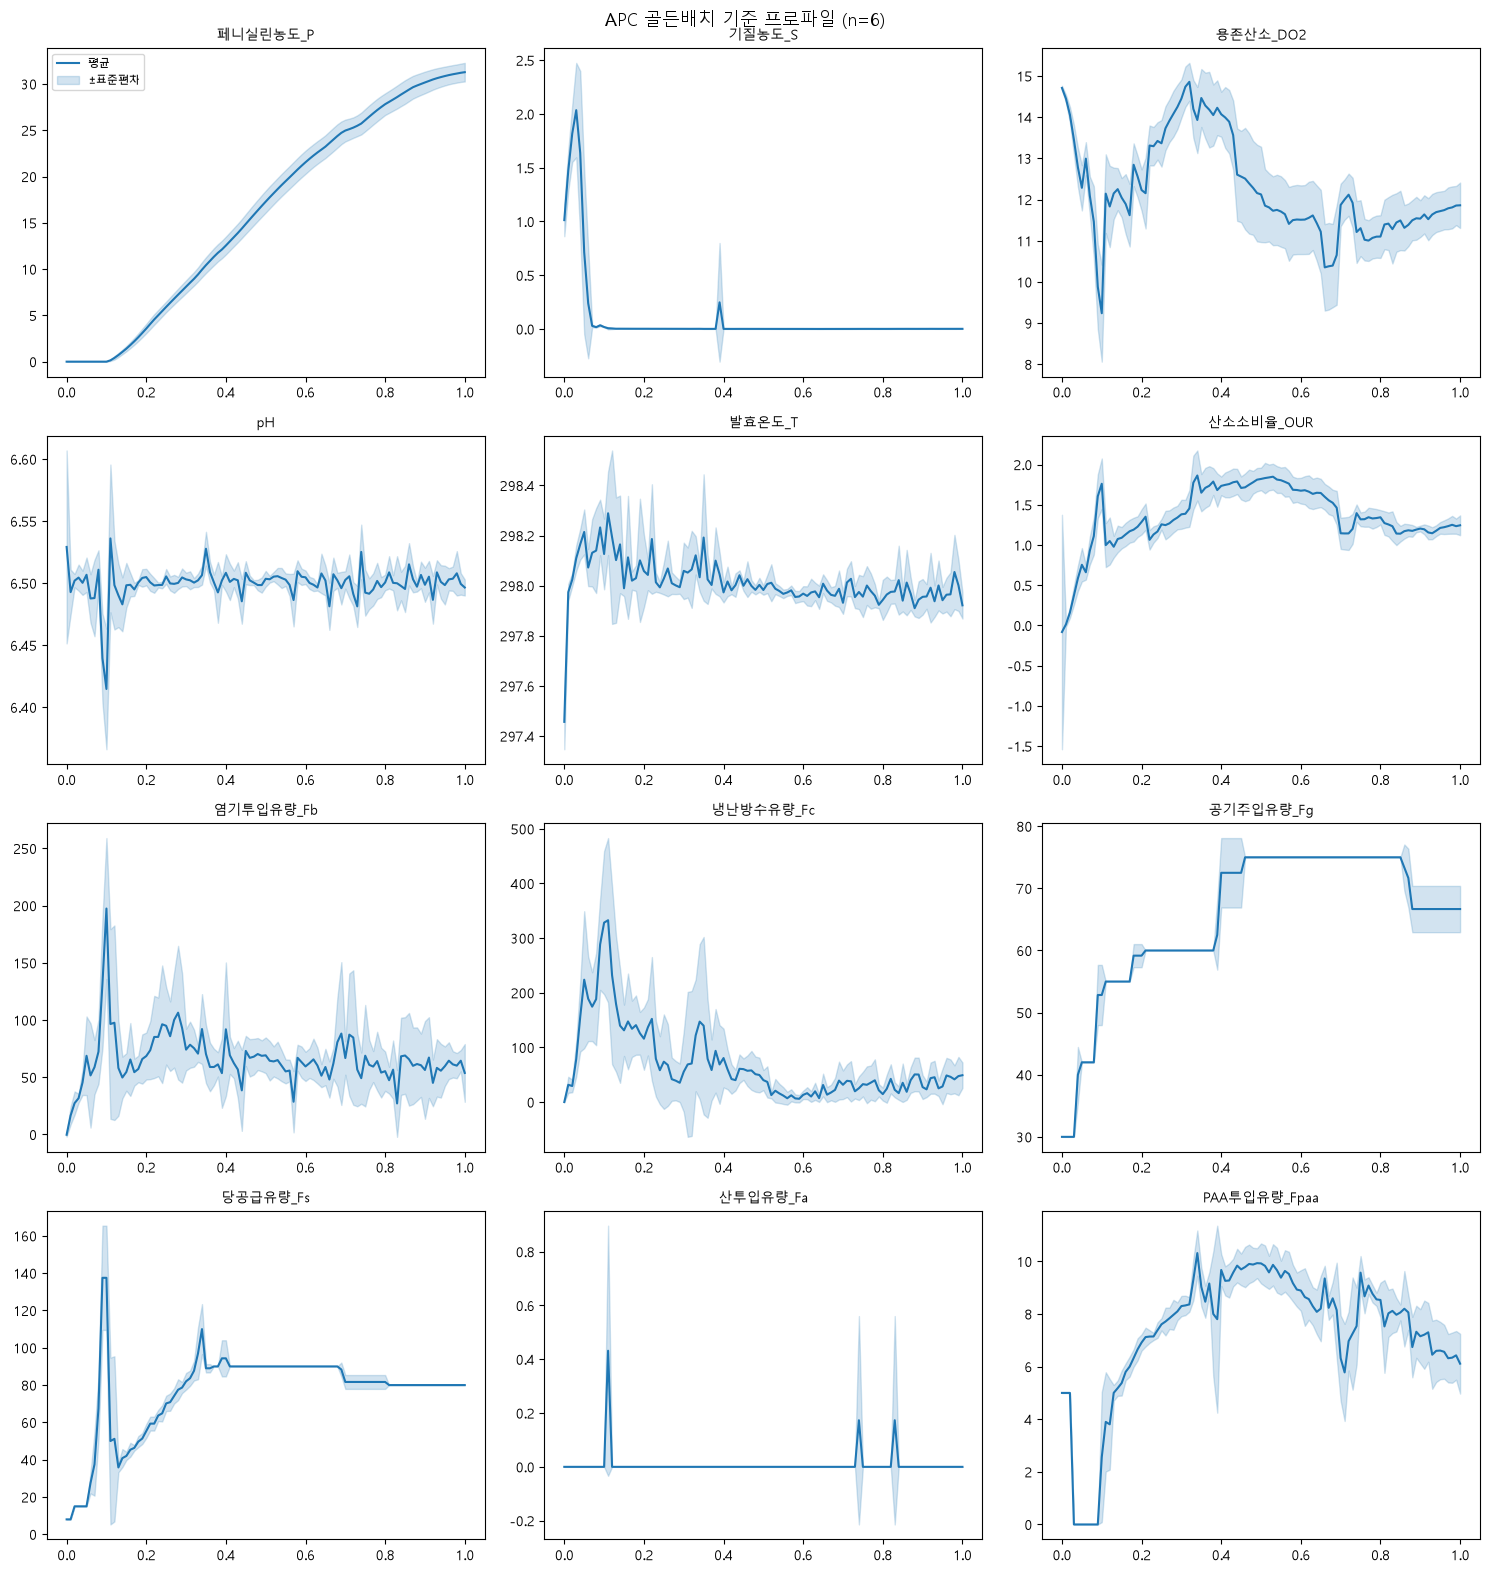

In [44]:
# 시각화 — 12개 변수 전략별 확인

def plot_golden_band(band, cols, strategy_name, n_batches):
    n = len(cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
    axes = axes.flatten()

    x = band['공정진행률']
    for i, col in enumerate(cols):
        ax = axes[i]
        mean = band[f'{col}_mean']
        std = band[f'{col}_std']

        ax.plot(x, mean, color='tab:blue', label='평균')
        ax.fill_between(x, mean-std, mean+std, color='tab:blue', alpha=0.2, label='±표준편차')
        ax.set_title(col, fontsize=10)
        if i == 0:
            ax.legend(fontsize=8)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'{strategy_name} 골든배치 기준 프로파일 (n={n_batches})', fontsize=13)
    plt.tight_layout()
    plt.show()

for strategy in golden_batches:
    plot_golden_band(bands[strategy], feature_cols, strategy, len(golden_batches[strategy]))